# Calibration Analysis



## Theory

### 1. Goal
Map a raw confidence score $s \in [0, 1]$ to a calibrated probability $\hat p$ so that predicted confidence matches empirical correctness. The calibrated output is always **$P(\text{correct}\,|\,s)$**, not probability of error.

---

### 2. Calibration methods implemented in UQLM

#### 2.1 Platt scaling (`method="platt"`)
$$\hat p = \sigma(a s + b) = \frac{1}{1 + e^{-(a s + b)}}$$

UQLM fits an sklearn `LogisticRegression` on each scorer column independently, using $(s_i, y_i)$ where $y_i \in \{0, 1\}$ is the binary correctness label. Best when the dataset is small and the miscalibration is roughly sigmoid-shaped.

*Intuition: learn a smooth sigmoid correction when raw scores are systematically over- or under-confident.*

---

#### 2.2 Isotonic regression (`method="isotonic"`)
$$\hat p = f(s), \quad f \text{ monotone non-decreasing}$$

UQLM fits an `IsotonicRegression(out_of_bounds="clip")` per scorer — so inputs outside the training range snap to the nearest boundary value. The learned $f$ is a non-parametric step function, chosen only from monotonic fits, so score *ordering* is preserved while the absolute level can be remapped (e.g. if the model gives many 0.8 scores but only 60% are truly correct, isotonic can remap 0.8 down to ~0.6). More flexible than Platt — can fit non-sigmoid shapes — but correspondingly more data-hungry.

*Intuition: same monotone direction as the raw score, but with flexible, data-driven vertical re-scaling.*

---

### 3. How UQLM applies calibration internally

UQLM calibrates **each scorer column independently**:
$$g_j: s_{i,j} \mapsto \hat p_{i,j}$$
then writes `calibrated_{scorer}` back into the `UQResult`.

Requirements enforced by the code:
- Labels must be binary $0/1$.
- Scorer values must lie in $[0, 1]$.
- Train- and transform-time scorer sets must match (error if not).

*(Implementation: `uqlm/calibration/score_calibrator.py`)*

---

### 4. Calibration quality metrics

`evaluate_calibration(...)` reports the following per scorer:

- **Average confidence** — mean of the predicted probabilities.
- **Average accuracy** — fraction of correct responses.
- **Calibration gap** — $|\text{avg conf} - \text{avg acc}|$; a quick global check for over- or under-confidence. Smaller is better.
- **Brier score** — $\tfrac{1}{N}\sum_i (\hat p_i - y_i)^2$; MSE of predicted probability vs true label.
- **Log loss** — $-\tfrac{1}{N}\sum_i [\,y_i \log \hat p_i + (1-y_i)\log(1-\hat p_i)\,]$; penalises overconfident wrong predictions heavily.
- **ECE** (Expected Calibration Error) — $\sum_{b=1}^{B} \tfrac{|I_b|}{N}\,|\text{acc}(I_b) - \text{conf}(I_b)|$; bins predictions by confidence, takes the weighted mean of the gap between bin accuracy and bin confidence.
- **MCE** (Maximum Calibration Error) — $\max_b |\text{acc}(I_b) - \text{conf}(I_b)|$; the worst-bin gap.

*(Implementation: `uqlm/calibration/evaluate.py`)*


## Ensemble Scorers (UQLM, Full List)

### 1. Off-the-shelf BS Detector (default if `scorers=None`)

$$\text{BSD}(y) = 0.56 \cdot \text{NCP}(y) + 0.14 \cdot \text{EMR}(y) + 0.30 \cdot J(y)$$

```python
components = ["noncontradiction", "exact_match", llm]   # llm acts as self-judge
weights    = [0.56, 0.14, 0.30]
```

A fixed, preconfigured mix of black-box consistency (`noncontradiction` + `exact_match`) and a self-judge LLM.
*Intuition: strong baseline with no setup.*

***

### 2. Custom weighted ensemble

```python
scorers = ["semantic_negentropy", "noncontradiction", llm]
weights = [0.5, 0.3, 0.2]   # same order as scorers
```

Any mix of black-box, white-box, and judge scorers is allowed; weights are normalised to sum to 1.
*Intuition: each scorer family captures a different uncertainty signal.*

***

### Allowed component types

1. **Black-box:** `semantic_negentropy`, `semantic_sets_confidence`, `noncontradiction`, `entailment`, `exact_match`, `bert_score`, `cosine_sim`.
2. **White-box:** `sequence_probability`, `min_probability`, `min_token_negentropy`, `mean_token_negentropy`, `probability_margin`, `semantic_negentropy`, `semantic_density`, `monte_carlo_probability`, `consistency_and_confidence`, `p_true`.
3. **Judge components:** any `BaseChatModel` or `LLMJudge`.

***

### Optional mitigation: `use_best=True`

```python
if use_best:
    # swap the original response with the uncertainty-minimized
    # candidate from the semantic-entropy clustering.
```

Applies only when black-box components are present (they produce the candidate clusters).
*Intuition: evaluate the best available candidate, not just the first draft.*

***

### Weight tuning on labelled data

`tune_from_graded(correct_indicators, weights_objective=..., thresh_objective=...)` optimises the weight vector:
$$w^* = \arg\max_w \; \text{Objective}(E_w, y_{\text{true}})$$

`weights_objective` options (7):

1. `roc_auc` — ranking quality over all thresholds *(default)*.
2. `fbeta_score` — thresholded precision/recall tradeoff.
3. `accuracy_score` — fraction correct.
4. `balanced_accuracy_score` — mean recall over classes (better for imbalance).
5. `average_precision` — PR-curve area (good for rare positives).
6. `log_loss` — probabilistic penalty; lower is better.
7. `brier_score` — probability calibration quality; lower is better.

***

### Threshold tuning (optional decision rule)

$$\hat y_i = \mathbf{1}[\,E_i > \tau\,]$$

`thresh_objective` options: `fbeta_score`, `accuracy_score`, `balanced_accuracy_score`.

```python
best_tau = tuner.tune_threshold(y_scores, y_true, thresh_objective="fbeta_score")
```

***

### Joint vs two-stage optimisation

Joint optimisation happens iff `weights_objective == thresh_objective`, which forces the weights objective to also be threshold-based. In particular:

- If `weights_objective` $\in$ \{`fbeta_score`, `accuracy_score`, `balanced_accuracy_score`\}: `thresh_objective` **must match** — the tuner validates this and raises otherwise, so those runs are always joint.
- If `weights_objective` $\in$ \{`roc_auc`, `average_precision`, `log_loss`, `brier_score`\}: these are ranking/probabilistic (not threshold-based), so joint mode is never used — weights are tuned first, then the threshold is picked via 1D grid search.

*Intuition: jointly optimise only when both targets depend on the same binary decision process.*

***

### Search method actually used

Under the hood `_optimize_objective` dispatches on the number of components $k$:

1. **Joint mode (same objective for weights and threshold):**
   - $k = 2$: grid search over $(w, \tau)$.
   - $k > 2$: Optuna over $(w_1, \dots, w_k, \tau)$ for `n_trials` trials.
2. **Two-stage mode (weights first, threshold second):**
   - Weights: grid search for $k \in \{2, 3\}$, Optuna for $k > 3$.
   - Threshold: 1D grid search on `thresh_bounds` with `step_size`.

Key knobs:
- `n_trials` — Optuna budget.
- `thresh_bounds` — `(low, high)` interval for the threshold search.
- `step_size` — resolution for both weight grid search and the threshold grid.
- `fscore_beta` — only affects `fbeta_score`.

***

### Practical usage patterns

1. Zero-config baseline: `UQEnsemble(llm=llm)` → BS Detector.
2. Manual custom mix: pass `scorers=[...]`, `weights=[...]`.
3. Data-driven tuning: `generate_and_score(...)` → `tune(...)` / `tune_from_graded(...)`.
4. Save/load tuned setup: `save_config(...)`, `load_config(...)`.


## Why we don't use Platt, isotonic, or UQEnsemble's tuner here

Everything above — Platt/isotonic calibration and `UQEnsemble.tune_from_graded` — assumes you have enough labelled examples **in both classes** to fit a data-driven curve or weight vector. Our setting does not.

**Data reality.** The expert-labelled ground-truth set has **195 tests**. Each ensemble slice we evaluate contains 325 checks, and test-level accuracy sits at ~93–96% (TABLE 1). That leaves only **about 7–15 error tests per ensemble** — the positives we actually want to rank. These positive counts are the real cap on anything that has to be fitted from data:

- **Isotonic regression** is non-parametric and tends to produce step functions that memorise the tiny positive sample. On 7–15 errors it collapses to a handful of breakpoints and is essentially unusable out-of-distribution.
- **Platt scaling** is less prone to overfitting, but still needs enough positives to estimate $(a, b)$ reliably; with this class imbalance the fitted sigmoid is dominated by the ~95% correct cases and barely separates the rare errors.
- **UQEnsemble's Optuna-tuned weights** face the same issue: optimising a 3–7-dimensional weight vector against `roc_auc` or `fbeta` on 7–15 positives is trivially overfittable; LOO-CV would show the fitted weights swinging wildly per fold.

**What we do instead.** We stay in a **ranking-first, calibration-free regime** and rely only on transformations that don't require fitting a probability curve to sparse positives:

1. **Per-scorer q05/q95 rescale** (`scale_to_error`) — a distribution-aware monotone transform that maps each scorer into a comparable `[0, 1]` range without touching the labels. This is the only per-scorer stretching we do; it's label-free, so it cannot overfit.
2. **Auto-flip orientation per scorer** — for each scorer we pick the sign (confidence-like vs error-like) that maximises test-level AP-error on the training set. Binary choice, not a fitted curve.
3. **Soft-OR check→test aggregation** (`CHECK_TO_TEST_AGG = soft_or`) — a noisy-OR that lifts a test to high uncertainty as soon as any of its checks fires. No parameters to fit.
4. **Equal-weight mean across scorers** in the final ensemble. We deliberately do *not* tune weights, because tuning them on 7–15 errors per ensemble would be noise-fitting; equal weighting is the honest baseline.
5. **Shared threshold via F1 + LOO-ensemble CV** on the aggregated score. One scalar knob, fit on many ensembles, evaluated held-out — by far the most data-efficient thing we can tune.

The rest of the notebook implements exactly this pipeline: it evaluates individual scorers (whitebox/blackbox) at the test level, selects the ensemble members by AP-error, and picks a shared threshold on the soft-OR aggregate. Calibration quality metrics (ECE/Brier/log-loss) would require trustworthy probabilities; since we don't produce those, we measure **ranking and decision-rule quality** instead (AP-error, F1 at the picked threshold, TP/FP/FN counts).

### What is AP-error and why is it the right metric here?

**Definition.** Average Precision (AP) is the area under the precision–recall curve, computed as a finite sum over the thresholds at which the ranked score crosses each test:

$$	ext{AP} = \sum_{n} (R_n - R_{n-1}) \cdot P_n$$

where $R_n$ and $P_n$ are recall and precision at the $n$-th threshold (sorted by descending score). It can be read as the expected precision averaged uniformly over recall — a single number summarising the entire PR curve.

**AP-error specifically.** We compute AP with the **error class as the positive class**: $y_	ext{true} = 	ext{error\_label}$ (1 if the model got the test wrong, 0 otherwise) and $y_	ext{score}$ = the test-level uncertainty score from check-to-test `soft_or` aggregation. In `sklearn` terms:

```python
from sklearn.metrics import average_precision_score
ap_error = average_precision_score(y_error_label, test_error_score)
```

This is what the helper functions return as `average_precision_error` and what the per-scorer ranking tables sort on.

**Why this metric for *this* problem.** Four reasons, all driven by the same constraint — errors are rare and we care about catching the rare cases:

1. **Class imbalance.** Errors are ~6% of tests. ROC-AUC weights TPR and FPR symmetrically across the whole curve and is dominated by the easy 94% of correct tests, so it inflates and saturates. PR-curve metrics like AP focus on the part of the ranking where the rare positives sit, which is exactly where we need separation.
2. **Threshold-free, but decision-relevant.** AP collapses the entire precision/recall trade-off into one number, so we can rank scorers and subsets *before* committing to a specific operating point τ. The threshold gets picked separately, downstream, against F1 + a recall floor — but the *first* selection step needs to be threshold-agnostic so we don't compound choices.
3. **Matches the reviewer use case.** A high AP-error means errors are concentrated near the top of the ranked uncertainty scores. That is literally what the reviewer workflow rewards: tests with the highest uncertainty get reviewed first, errors get caught earliest. ROC-AUC does not have this interpretation when prevalence is low.
4. **Comparable across scorers and ensembles.** Because AP is computed on the per-test ranking it does not depend on the choice of τ, the choice of orientation flip (we pick the orientation that maximises it), or the size of the flag budget. That stability lets us compare scorers across the four base models in TABLE 2b/3b and across the five GPT20B ensembles in the multi-ensemble cell using the same yardstick.

**Lift over baseline.** A constant predictor scores AP equal to the positive-class prevalence (~0.06 here). The helper reports `ap_error_lift_over_baseline` = `average_precision_error − prevalence`, which is the more honest "how much better than random" number. A scorer with AP-error = 0.20 on a 6%-positive set has lift ≈ 0.14 — substantial, even though 0.20 sounds modest in absolute terms.

**What AP-error does NOT tell you.** It is a ranking metric. Two scorers can have identical AP-error but very different *operating-point* behaviour at a fixed τ (precision, recall, flag count). That's why AP-error decides *scorer selection* but the *threshold pick* downstream uses F1 with explicit recall and flag-count constraints — different metrics for different questions.

## Comparing Model Performance and UE Methods

### Data preparation and test-level aggregation

All raw UQLM and judge scores live at the **check level**, while the target `match` is a **test-level** correctness flag repeated across checks of the same test. Every analysis in this notebook works at the test level, so the pipeline converts check-level scores into per-test uncertainty estimates in the same way throughout.

Each raw scorer is re-oriented so that larger values consistently mean *more likely model error*, then scaled to `[0, 1]` using quantile clipping `[q05, q95]`. For cross-model and pre-calibration diagnostics, check-level error scores are collapsed to a single test-level score with plain **soft-OR**:

$$u_{test} = 1 - \prod_i (1 - u_i)$$



In [6]:
# Global setup
from pathlib import Path
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    average_precision_score
)

from calibration_helpers import (
    CHECK_KEY,
    TEST_KEY,
    THRESHOLDS,
    add_model_error_target,
    build_test_work,
    evaluate_metric,
    evaluate_metric_files,
    learn_global_orientation_and_bounds,
    make_gated_soft_or,
    per_threshold_summary,
    require_constant_within_tests,
    soft_or,
    threshold_metrics,
)

DATA_DIR = Path(r"data")
TARGET_BASE_MODEL = "GPT20B"
ENSEMBLE_IDS = [1, 2, 3, 4, 5]


SCALE = True

# Per-scorer scaling bounds.
PROD_Q_LOW = 0.05
PROD_Q_HIGH = 0.95


DIAGNOSTIC_AGG = soft_or
DIAGNOSTIC_AGG_NAME = getattr(DIAGNOSTIC_AGG, "__name__", repr(DIAGNOSTIC_AGG))





### Cross-model comparison tables

This cell compares the available uncertainty signals across base models before the final GPT20B calibration.

It loads whitebox UQLM scores, blackbox UQLM scores, and judge scores. Since all scores live at check level but correctness is evaluated at test level, each scorer is first converted into an error-oriented score, then aggregated to test level using `soft_or`.

The cell automatically flips scorers when necessary so that higher values consistently mean “more likely model error”. It then compares scorer families using AP-error, which measures how well each uncertainty signal ranks wrong model answers above correct ones.

The output tables show:

- direct model accuracy by answer source,
- family-level uncertainty performance,
- judge-model performance.




In [7]:
# ============================================================================
# Cross-model comparison tables 
# ============================================================================
CROSS_MODEL_AGG = soft_or
CROSS_MODEL_AGG_NAME = getattr(CROSS_MODEL_AGG, "__name__", repr(CROSS_MODEL_AGG))

from calibration_helpers import (
    EXCLUDE_SCORE_COLS,
    parse_wb_bb,
    norm_score,
    scale_to_error,
    summarize_ranking,
)


def _collect_family_long(prefix):
    parts = []
    for path in sorted(p for p in DATA_DIR.glob(f"{prefix}*.csv") if ".bak_" not in p.name):
        _, base_model = parse_wb_bb(path.name, prefix)
        if base_model is None:
            continue
        df = pd.read_csv(path)
        if "match" not in df.columns:
            continue
        score_cols = [c for c in df.columns if c not in EXCLUDE_SCORE_COLS]
        for method in score_cols:
            cols = [c for c in CHECK_KEY + ["match", method] if c in df.columns]
            if len(cols) < len(CHECK_KEY) + 2:
                continue
            d = add_model_error_target(df[cols].copy(), "match")
            d["raw_score"] = norm_score(d[method])
            d = d.dropna(subset=["raw_score"])
            if d.empty:
                continue
            d["base_model"] = base_model
            d["method"] = method
            parts.append(d[["base_model"] + CHECK_KEY + ["label", "error_label", "raw_score", "method"]])
    out_cols = ["base_model"] + CHECK_KEY + ["label", "error_label", "raw_score", "method"]
    if not parts:
        return pd.DataFrame(columns=out_cols)
    out = pd.concat(parts, ignore_index=True)
    require_constant_within_tests(out, "label", prefix, group_cols=["base_model", "method"])
    return out


def _collect_source_test_accuracy(prefix):
    parts = []
    for path in sorted(p for p in DATA_DIR.glob(f"{prefix}*.csv") if ".bak_" not in p.name):
        _, base_model = parse_wb_bb(path.name, prefix)
        if base_model is None:
            continue
        df = pd.read_csv(path)
        if "match" not in df.columns:
            continue
        cols = [c for c in CHECK_KEY + ["match"] if c in df.columns]
        if len(cols) < len(CHECK_KEY) + 1:
            continue
        d = add_model_error_target(df[cols].copy(), "match")
        if d.empty:
            continue
        require_constant_within_tests(d, "label", f"{prefix} accuracy")
        test_df = d.groupby(TEST_KEY, as_index=False).agg(label=("label", "first"))
        test_df["base_model"] = base_model
        parts.append(test_df[["base_model"] + TEST_KEY + ["label"]])
    if not parts:
        return pd.DataFrame(columns=["base_model"] + TEST_KEY + ["label"])
    return pd.concat(parts, ignore_index=True)


def _collect_judge_long(filename="judge_case_by_model.csv"):
    path = DATA_DIR / filename
    jraw = pd.read_csv(path)
    judge_req = ["base_model", "judge_model", "source"] + CHECK_KEY + ["label", "score"]
    judge_df = jraw[judge_req].copy().rename(columns={"label": "match"})
    judge_df["source"] = judge_df["source"].astype(str).str.strip().str.lower()
    judge_df = judge_df[judge_df["source"].isin(["whitebox", "blackbox"])].copy()
    judge_df = add_model_error_target(judge_df, "match")
    judge_df["raw_score"] = norm_score(judge_df["score"])
    judge_df = judge_df.dropna(subset=["raw_score"])
    return judge_df[
        ["base_model", "judge_model", "source"] + CHECK_KEY + ["label", "error_label", "raw_score"]
    ]


def _orient_group_to_error(group, agg_fn):
    group = group.copy()
    raw = group["raw_score"].to_numpy(dtype=float)
    y_error_key = (
        group[TEST_KEY + ["error_label"]]
        .drop_duplicates(TEST_KEY)
        .sort_values(TEST_KEY)["error_label"]
        .astype(int)
        .to_numpy()
    )
    best = None
    for flipped in (False, True):
        oriented = -raw if flipped else raw
        check_error_score, lo, hi = scale_to_error(oriented)
        temp = group[TEST_KEY + ["error_label"]].copy()
        temp["check_error_score"] = check_error_score
        test_df = (
            temp.groupby(TEST_KEY, as_index=False)
            .agg(
                error_label=("error_label", "first"),
                test_error_score=("check_error_score", agg_fn),
            )
            .dropna(subset=["test_error_score"])
            .sort_values(TEST_KEY)
            .reset_index(drop=True)
        )
        if len(test_df) == 0 or np.unique(y_error_key).size < 2:
            ap_error = float("nan")
        else:
            ap_error = float(
                average_precision_score(
                    y_error_key, test_df["test_error_score"].to_numpy(dtype=float)
                )
            )
        candidate = {
            "flipped": bool(flipped),
            "error_score": check_error_score,
            "ap_error": ap_error,
            "q05": lo,
            "q95": hi,
        }
        key = np.nan_to_num(ap_error, nan=-np.inf)
        if best is None or key > best[0]:
            best = (key, candidate)

    group["error_score"] = best[1]["error_score"]
    group["flipped"] = best[1]["flipped"]
    group["q05"] = best[1]["q05"]
    group["q95"] = best[1]["q95"]
    return group


def _aggregate_family_to_tests(df, group_cols, component_col, agg_fn):
    out_cols = group_cols + TEST_KEY + ["label", "error_label", "score", "test_error_score"]
    if df.empty:
        return pd.DataFrame(columns=out_cols)
    require_constant_within_tests(
        df, "label", ",".join(group_cols) or "family", group_cols=group_cols
    )
    component_cols = group_cols if component_col in group_cols else group_cols + [component_col]

    component_test_df = (
        df.groupby(component_cols + TEST_KEY, dropna=False)
        .agg(
            label=("label", "first"),
            test_error_score=("error_score", agg_fn),
        )
        .reset_index()
    )

    if component_col in group_cols:
        test_df = component_test_df.copy()
    else:
        test_df = (
            component_test_df.groupby(group_cols + TEST_KEY, dropna=False)
            .agg(
                label=("label", "first"),
                test_error_score=("test_error_score", "mean"),
            )
            .reset_index()
        )

    test_df["label"] = test_df["label"].round().astype(int)
    test_df["error_label"] = 1 - test_df["label"]
    test_df["score"] = 1.0 - test_df["test_error_score"]
    return test_df[out_cols]


# ---- Collect and orient ---------------------------------------------------
wb_long = _collect_family_long("uqlm_whitebox_")
bb_long = _collect_family_long("uqlm_blackbox_")
wb_accuracy_tests = _collect_source_test_accuracy("uqlm_whitebox_")
bb_accuracy_tests = _collect_source_test_accuracy("uqlm_blackbox_")
judge_long = _collect_judge_long("judge_case_by_model.csv")

wb_oriented = wb_long.groupby(["base_model", "method"], group_keys=False).apply(
    lambda g: _orient_group_to_error(g, CROSS_MODEL_AGG)
)
bb_oriented = bb_long.groupby(["base_model", "method"], group_keys=False).apply(
    lambda g: _orient_group_to_error(g, CROSS_MODEL_AGG)
)
judge_oriented = judge_long.groupby(
    ["base_model", "judge_model", "source"], group_keys=False
).apply(lambda g: _orient_group_to_error(g, CROSS_MODEL_AGG))

wb_oriented = wb_oriented.assign(family="whitebox")
bb_oriented = bb_oriented.assign(family="blackbox")
judge_oriented = judge_oriented.assign(
    family=judge_oriented["source"].map(
        {"whitebox": "judge_whitebox", "blackbox": "judge_blackbox"}
    )
)

# ---- Family-level and judge-level test aggregates -------------------------
wb_test = _aggregate_family_to_tests(
    wb_oriented, ["base_model", "family"], "method", CROSS_MODEL_AGG
)
bb_test = _aggregate_family_to_tests(
    bb_oriented, ["base_model", "family"], "method", CROSS_MODEL_AGG
)
judge_family_tests = _aggregate_family_to_tests(
    judge_oriented, ["base_model", "family"], "judge_model", CROSS_MODEL_AGG
)
judge_test_by_model = _aggregate_family_to_tests(
    judge_oriented,
    ["base_model", "judge_model", "source"],
    "judge_model",
    CROSS_MODEL_AGG,
)

# ---- Align common test sets per answer source -----------------------------
wb_keys = wb_test[["base_model"] + TEST_KEY].drop_duplicates()
bb_keys = bb_test[["base_model"] + TEST_KEY].drop_duplicates()
jd_wb_keys = judge_family_tests[judge_family_tests["family"] == "judge_whitebox"][
    ["base_model"] + TEST_KEY
].drop_duplicates()
jd_bb_keys = judge_family_tests[judge_family_tests["family"] == "judge_blackbox"][
    ["base_model"] + TEST_KEY
].drop_duplicates()

common_wb = wb_keys.merge(jd_wb_keys, on=["base_model"] + TEST_KEY, how="inner")
common_bb = bb_keys.merge(jd_bb_keys, on=["base_model"] + TEST_KEY, how="inner")

# ---- TABLE 1: test-level accuracy by base model and answer source ---------
wb_accuracy_eq = wb_accuracy_tests.merge(common_wb, on=["base_model"] + TEST_KEY, how="inner")
bb_accuracy_eq = bb_accuracy_tests.merge(common_bb, on=["base_model"] + TEST_KEY, how="inner")

table1_rows = []
for (bm,), g in wb_accuracy_eq.groupby(["base_model"], dropna=False):
    table1_rows.append({"base_model": bm, "answer_source": "whitebox", "accuracy": float(g["label"].mean())})
for (bm,), g in bb_accuracy_eq.groupby(["base_model"], dropna=False):
    table1_rows.append({"base_model": bm, "answer_source": "blackbox", "accuracy": float(g["label"].mean())})

table1 = pd.DataFrame(table1_rows).sort_values(["base_model", "answer_source"]).reset_index(drop=True)

# ---- TABLE 2: family-level UE performance ---------------------------------
wb_test_eq = wb_test.merge(common_wb, on=["base_model"] + TEST_KEY, how="inner")
bb_test_eq = bb_test.merge(common_bb, on=["base_model"] + TEST_KEY, how="inner")
jd_wb_test_eq = judge_family_tests[judge_family_tests["family"] == "judge_whitebox"].merge(
    common_wb, on=["base_model"] + TEST_KEY, how="inner"
)
jd_bb_test_eq = judge_family_tests[judge_family_tests["family"] == "judge_blackbox"].merge(
    common_bb, on=["base_model"] + TEST_KEY, how="inner"
)

fam_test_df = pd.concat(
    [wb_test_eq, jd_wb_test_eq, bb_test_eq, jd_bb_test_eq], ignore_index=True
)
if fam_test_df.empty:
    raise RuntimeError("No aligned tests found for whitebox/judge_whitebox or blackbox/judge_blackbox.")

rows = []
for (bm, fam), g in fam_test_df.groupby(["base_model", "family"], dropna=False):
    rows.append(
        {"base_model": bm, "family": fam, **summarize_ranking(g["label"].values, g["score"].values)}
    )
table2 = pd.DataFrame(rows).sort_values(["base_model", "family"]).reset_index(drop=True)

# ---- TABLE 2b: family-level with combined judge row -----------------------
judge_mask = table2["family"].isin(["judge_whitebox", "judge_blackbox"])
judge_part = table2[judge_mask].copy()
other_part = table2[~judge_mask].copy()

judge_avg = pd.DataFrame()
if not judge_part.empty:
    judge_avg = (
        judge_part.groupby(["base_model"], dropna=False)
        .agg(
            correct_rate=("correct_rate", "mean"),
            model_error_rate=("model_error_rate", "mean"),
            average_precision=("average_precision", "mean"),
            ap_lift_over_baseline=("ap_lift_over_baseline", "mean"),
            average_precision_error=("average_precision_error", "mean"),
            ap_error_lift_over_baseline=("ap_error_lift_over_baseline", "mean"),
        )
        .reset_index()
    )
    judge_avg["family"] = "judge"

table2_combined = pd.concat([other_part, judge_avg], ignore_index=True)
table2_combined["_model_top_ape"] = table2_combined.groupby("base_model")["average_precision_error"].transform("max")
table2_combined = (
    table2_combined
    .sort_values(
        ["_model_top_ape", "base_model", "average_precision_error", "ap_error_lift_over_baseline"],
        ascending=[False, True, False, False],
    )
    .drop(columns="_model_top_ape")
    .reset_index(drop=True)
)

# ---- TABLE 3b: judge detail averaged across whitebox/blackbox -------------
judge_eq = pd.concat(
    [
        judge_test_by_model[judge_test_by_model["source"] == "whitebox"].merge(
            common_wb, on=["base_model"] + TEST_KEY, how="inner"
        ),
        judge_test_by_model[judge_test_by_model["source"] == "blackbox"].merge(
            common_bb, on=["base_model"] + TEST_KEY, how="inner"
        ),
    ],
    ignore_index=True,
)

judge_table = pd.DataFrame()
if not judge_eq.empty:
    rows = []
    for (bm, jm, src), g in judge_eq.groupby(
        ["base_model", "judge_model", "source"], dropna=False
    ):
        rows.append(
            {
                "base_model": bm,
                "judge_model": jm,
                "source": src,
                **summarize_ranking(g["label"].values, g["score"].values),
            }
        )
    judge_table = pd.DataFrame(rows).sort_values(
        ["base_model", "source", "average_precision_error", "ap_error_lift_over_baseline"],
        ascending=[True, True, False, False],
    ).reset_index(drop=True)

judge_table_avg = pd.DataFrame()
if not judge_table.empty:
    judge_table_avg = (
        judge_table.groupby(["base_model", "judge_model"], dropna=False)
        .agg(
            correct_rate=("correct_rate", "mean"),
            model_error_rate=("model_error_rate", "mean"),
            average_precision=("average_precision", "mean"),
            average_precision_error=("average_precision_error", "mean"),
            ap_lift_over_baseline=("ap_lift_over_baseline", "mean"),
            ap_error_lift_over_baseline=("ap_error_lift_over_baseline", "mean"),
        )
        .reset_index()
    )
    judge_table_avg["_model_top_ape"] = judge_table_avg.groupby("base_model")["average_precision_error"].transform("max")
    judge_table_avg = (
        judge_table_avg
        .sort_values(
            ["_model_top_ape", "base_model", "average_precision_error", "ap_error_lift_over_baseline"],
            ascending=[False, True, False, False],
        )
        .drop(columns="_model_top_ape")
        .reset_index(drop=True)
    )

# ---- Display --------------------------------------------------------------
print(f"\nTABLE 1 - Direct test-level accuracy by base model and answer source (agg={CROSS_MODEL_AGG_NAME})")
display(table1[["base_model", "answer_source", "accuracy"]])

print(f"\nTABLE 2b - Family-level performance with combined judge row (agg={CROSS_MODEL_AGG_NAME})")
display(
    table2_combined[
        ["base_model", "family", "average_precision", "average_precision_error", "ap_error_lift_over_baseline"]
    ]
)

print(f"\nTABLE 3b - Judge detail averaged across whitebox/blackbox (agg={CROSS_MODEL_AGG_NAME})")
display(
    judge_table_avg[
        ["base_model", "judge_model", "average_precision_error", "ap_error_lift_over_baseline"]
    ]
)



C:\Users\Feresh\AppData\Local\Temp\ipykernel_11512\4225578695.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wb_oriented = wb_long.groupby(["base_model", "method"], group_keys=False).apply(
C:\Users\Feresh\AppData\Local\Temp\ipykernel_11512\4225578695.py:183: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bb_oriented = bb_long.groupby(["base_model", "method"], group_keys=False).apply(
C:\Users\Feresh\AppData\Lo


TABLE 1 - Direct test-level accuracy by base model and answer source (agg=soft_or)


,base_model,answer_source,accuracy
0,GEMINI_2.5_flashlite,blackbox,0.934066
1,GEMINI_2.5_flashlite,whitebox,0.917127
2,GPT20B,blackbox,0.945055
3,GPT20B,whitebox,0.934066
4,MISTRAL_24B,blackbox,0.961538
5,MISTRAL_24B,whitebox,0.961538
6,QWEN_32B,blackbox,0.928571
7,QWEN_32B,whitebox,0.928571



TABLE 2b - Family-level performance with combined judge row (agg=soft_or)


,base_model,family,average_precision,average_precision_error,ap_error_lift_over_baseline
0,QWEN_32B,blackbox,0.952875,0.134325,1.880553
1,QWEN_32B,whitebox,0.956106,0.098305,1.376269
2,QWEN_32B,judge,0.917798,0.066991,0.937870
3,GEMINI_2.5_flashlite,whitebox,0.956621,0.126647,1.528213
4,GEMINI_2.5_flashlite,blackbox,0.951348,0.076245,1.156387
5,GEMINI_2.5_flashlite,judge,0.918593,0.073015,0.983248
6,GPT20B,blackbox,0.953356,0.112145,2.041044
7,GPT20B,whitebox,0.948654,0.085697,1.299739
8,GPT20B,judge,0.935154,0.061447,1.008611
9,MISTRAL_24B,whitebox,0.971701,0.049416,1.284816



TABLE 3b - Judge detail averaged across whitebox/blackbox (agg=soft_or)


,base_model,judge_model,average_precision_error,ap_error_lift_over_baseline
0,GEMINI_2.5_flashlite,GEMINI_2.5_flash,0.073015,0.983248
1,GEMINI_2.5_flashlite,GPT120B,0.073015,0.983248
2,GEMINI_2.5_flashlite,MISTRAL3_LARGE,0.073015,0.983248
3,GEMINI_2.5_flashlite,QWEN_235B,0.073015,0.983248
4,QWEN_32B,GEMINI_2.5_flash,0.066991,0.937870
5,QWEN_32B,GPT120B,0.066991,0.937870
6,QWEN_32B,MISTRAL3_LARGE,0.066991,0.937870
7,QWEN_32B,QWEN_235B,0.066991,0.937870
8,GPT20B,GEMINI_2.5_flash,0.061447,1.008611
9,GPT20B,GPT120B,0.061447,1.008611


The direct accuracy table shows that all base models are already highly accurate, with test-level accuracy between about 92.9% and 96.2%. MISTRAL_24B is the strongest model in this set, while QWEN_32B is the weakest. GPT20B is in the middle: its blackbox answers are slightly more accurate than its whitebox answers.

The family-level AP-error table compares how useful each uncertainty family is for detecting model errors. Here, `average_precision_error` is the most relevant column: higher values mean the uncertainty signal ranks wrong answers above correct answers more effectively.

Across models, the blackbox uncertainty family is generally the strongest. For GPT20B, blackbox uncertainty reaches the highest AP-error (`0.112`), followed by whitebox uncertainty (`0.086`), while the judge family is clearly weaker (`0.061`). For QWEN_32B and GEMINI_2.5_flashlite, the same pattern appears: blackbox or whitebox uncertainty signals outperform judge-based scores.

The judge-detail table shows that the choice of judge model barely changes performance. For GEMINI_2.5_flashlite, QWEN_32B, and GPT20B, all judge models have identical AP-error values. For MISTRAL_24B, MISTRAL3_LARGE is only slightly better, but the difference is very small. This suggests that the judge-score family is not limited by the specific judge model; rather, judge scores themselves are less informative for this broad uncertainty-ranking task.

Overall, these diagnostics support using blackbox uncertainty signals, especially entailment/noncontradiction-style consistency measures, as the basis for GPT20B calibration. Judge scores are useful later as a second-stage filter, but they are not the strongest primary uncertainty signal.



## Comparing Scorrers Within Whitebox 

In [9]:
WHITEBOX_METRICS = [
    "sequence_probability",
    "min_probability",
    "mean_token_negentropy",
    "min_token_negentropy",
    "probability_margin",
    "semantic_negentropy",
    "semantic_density",
    "monte_carlo_probability",
    "consistency_and_confidence",
    "p_true",
]

# Descriptive diagnostic table: uses plain soft_or and q05/q95 scaling.
# This is independent of the later gated production calibration.
whitebox_results = evaluate_metric_files(
    file_glob=str(DATA_DIR / "uqlm_whitebox_*.csv"),
    prefix="uqlm_whitebox_",
    metrics=WHITEBOX_METRICS,
    auto_flip=True,
    agg_fn=DIAGNOSTIC_AGG,
    scale=SCALE,
)

print("Target: test-level model error detection")
print((
    f"Aggregation from checks to tests: {DIAGNOSTIC_AGG_NAME} "
    f"over oriented check-level error scores (scale={SCALE}, q_low=0.05, q_high=0.95)"
))
display(whitebox_results)



Target: test-level model error detection
Aggregation from checks to tests: soft_or over oriented check-level error scores (scale=True, q_low=0.05, q_high=0.95)


,model,metric,model_error_rate,average_precision,ap_lift_over_baseline,average_precision_error,ap_error_lift_over_baseline,roc_auc_error,brier_error,flipped,q05,q95
0,GEMINI_2.5_flashlite,min_probability,0.082873,0.970167,1.057832,0.208722,2.518582,0.762249,0.553677,True,-0.482179,-0.185472
1,GEMINI_2.5_flashlite,consistency_and_confidence,0.082873,0.949861,1.035692,0.180864,2.182428,0.642169,0.446198,True,-0.895377,-0.767733
2,GEMINI_2.5_flashlite,monte_carlo_probability,0.082873,0.947134,1.032718,0.158982,1.918380,0.625502,0.462059,True,-0.912053,-0.813812
3,GEMINI_2.5_flashlite,min_token_negentropy,0.082873,0.972311,1.060170,0.158912,1.917543,0.742771,0.567661,True,-0.263220,-0.000001
4,GEMINI_2.5_flashlite,sequence_probability,0.082873,0.958854,1.045498,0.141908,1.712358,0.662450,0.370850,True,-0.936674,-0.845434
5,GEMINI_2.5_flashlite,mean_token_negentropy,0.082873,0.963472,1.050533,0.130737,1.577555,0.676908,0.163613,True,-0.906240,-0.000001
6,GEMINI_2.5_flashlite,probability_margin,0.082873,0.957044,1.043524,0.123008,1.484301,0.645181,0.164449,True,-0.907185,-0.000001
7,GEMINI_2.5_flashlite,p_true,0.082873,0.939204,1.024072,0.099158,1.196510,0.584337,0.186157,True,-0.999986,-0.152932
8,GEMINI_2.5_flashlite,semantic_density,0.082873,0.914800,0.997462,0.089023,1.074212,0.510040,0.529627,False,0.780238,0.918336
9,GEMINI_2.5_flashlite,semantic_negentropy,0.082873,0.907985,0.990032,0.080096,0.966496,0.425502,0.431544,False,0.999999,0.999999


Results suggest that the most useful whitebox metric depends on the base model, but consistency_and_confidence and monte_carlo_probability,appear the most consistently informative across models. Semantic desity only for GPT20B and QWEN32B

## Comparing Scorrers Within Blackbox

In [10]:
BLACKBOX_METRICS = [
    "semantic_negentropy_bb",
    "semantic_sets_confidence",
    "noncontradiction",
    "entailment",
    "exact_match",
    "cosine_sim",
    "bert_score",
]

# Descriptive diagnostic table: uses plain soft_or and q05/q95 scaling.
# This is independent of the later gated production calibration.
blackbox_results = evaluate_metric_files(
    file_glob=str(DATA_DIR /"uqlm_blackbox_*.csv"),
    prefix="uqlm_blackbox_",
    metrics=BLACKBOX_METRICS,
    auto_flip=True,
    agg_fn=DIAGNOSTIC_AGG,
    scale=SCALE,
)

print("Target: test-level model error detection")
print((
    f"Aggregation from checks to tests: {DIAGNOSTIC_AGG_NAME} "
    f"over oriented check-level error scores (scale={SCALE}, q_low=0.05, q_high=0.95)"
))
display(blackbox_results)



Target: test-level model error detection
Aggregation from checks to tests: soft_or over oriented check-level error scores (scale=True, q_low=0.05, q_high=0.95)


,model,metric,model_error_rate,average_precision,ap_lift_over_baseline,average_precision_error,ap_error_lift_over_baseline,roc_auc_error,brier_error,flipped,q05,q95
0,GEMINI_2.5_flashlite,bert_score,0.065934,0.954574,1.021955,0.143488,2.176235,0.617402,0.531646,True,-0.949744,-0.873638
1,GEMINI_2.5_flashlite,noncontradiction,0.065934,0.962864,1.030831,0.099599,1.510583,0.612745,0.391523,True,-0.964357,-0.797122
2,GEMINI_2.5_flashlite,entailment,0.065934,0.924388,0.989639,0.093268,1.414567,0.538725,0.633875,False,0.507117,0.847057
3,GEMINI_2.5_flashlite,cosine_sim,0.065934,0.943341,1.009929,0.076094,1.154085,0.524020,0.445064,True,-0.962241,-0.881576
4,GEMINI_2.5_flashlite,semantic_sets_confidence,0.065934,0.934842,1.000830,0.066667,1.011111,0.480882,0.923076,False,0.750000,0.999999
5,GEMINI_2.5_flashlite,semantic_negentropy_bb,0.065934,0.934842,1.000830,0.066667,1.011111,0.475000,0.923076,False,0.666099,0.999999
6,GEMINI_2.5_flashlite,exact_match,0.065934,0.929200,0.994791,0.065934,1.000000,0.442647,0.433293,False,0.000001,0.000001
7,GPT20B,bert_score,0.054945,0.957948,1.013643,0.127621,2.322703,0.610465,0.492689,True,-0.921665,-0.868584
8,GPT20B,noncontradiction,0.054945,0.965650,1.021792,0.108766,1.979545,0.658140,0.336331,True,-0.980317,-0.784871
9,GPT20B,cosine_sim,0.054945,0.954932,1.010452,0.073115,1.330694,0.518023,0.382212,True,-0.946564,-0.831795


Overall, the blackbox results are more consistent than the whitebox results: bert_score and noncontradiction are strong across most models.

### Usefull Whitebox Metrics:


#### Best per Model

For GEMINI_2.5_flashlit: `min_probability`, `consistency_and_confidence`, `monte_carlo_probability`

For GPT20B: `consistency_and_confidence`, `semantic_density`, `monte_carlo_probability`

For MISTRAL_24B: `mean_token_negentropy`, `sequence_probability`, `probability_margin`

For QWEN_32B: `monte_carlo_probability`, `semantic_density`, `consistency_and_confidence`


### Usefull Blackbox Metrics:

- `noncontradiction`
- `bert_score`
- `entailment` or `cosine similairty`

So based on the average percision error I would make an ensemble of:  

- Whitebox: `consistency_and_confidence` and  `monte_carlo_probability` because they are not only the strongest for GPT20B but also overall across other models as well. Could also add `semantic_density` that seems to work well for GPT20B and QWEN32B

- Blackbox: `bert_score` and `noncontradiction` and `entailment`.

- Judge: Rather not use that.


### Per-scorer behaviour across GPT20B ensembles

This cell evaluates each uncertainty scorer separately based on 5 sample answers of GPT20B only since it was the chosen base model for production, then averages the results across the five runs. The goal is to reduce dependence on one stochastic dataset and obtain more stable estimates of scorer quality.

For each ensemble version, scorer outputs are converted into comparable error scores, aggregated from checks to tests with the current diagnostic aggregation, and evaluated for how well they detect model errors. 



In [11]:
# final calibration. The final calibration derives gate = threshold - 0.10. This helps keep the noise out if the scores are 0.1 lower than threshhold otherwise
# they increase the uncertainty while each giving a low unsertainty score. This is only used for GPT20 only later on.
MIN_THRESHOLD_GATE_GAP = 0.10

CHECK_TO_TEST_AGG = soft_or
CHECK_TO_TEST_AGG_NAME = getattr(CHECK_TO_TEST_AGG, "__name__", repr(CHECK_TO_TEST_AGG))

SCORERS = [
    "noncontradiction",
    "entailment",
    "bert_score",
    "consistency_and_confidence",
    "monte_carlo_probability",
    "semantic_density"
]

FAMILY_MAP = {
    "noncontradiction": "blackbox",
    "entailment": "blackbox",
    "bert_score": "blackbox",
    "consistency_and_confidence": "whitebox",
    "monte_carlo_probability": "whitebox",
    "semantic_density": "whitebox",
}

# All six scorers carry signal on the Ensemble1..5 runs for GPT20B.
DEGENERATE_FOR_GPT20B = set()

TABLE_COLS = [
    "family",
    "scorer",
    "model_error_rate",
    "average_precision",
    "ap_lift_over_baseline",
    "average_precision_error",
    "ap_error_lift_over_baseline",
    "roc_auc_error",
    "brier_error",
    "flipped",
    "q05",
    "q95",
]


def evaluate_one_ensemble(ensemble_id):
    files = sorted(DATA_DIR.glob(f"GPT20_Ensemble{ensemble_id}_*.csv"))
    if not files:
        raise FileNotFoundError(f"No files found for Ensemble {ensemble_id}")

    df = pd.concat([pd.read_csv(path) for path in files], ignore_index=True)

    if "base_model" in df.columns:
        df = df[df["base_model"] == TARGET_BASE_MODEL].copy()

    if df.empty:
        raise RuntimeError(
            f"No rows found for base_model={TARGET_BASE_MODEL} in Ensemble {ensemble_id}"
        )
    if "match" not in df.columns:
        raise ValueError(f"Column 'match' is missing in Ensemble {ensemble_id}")

    rows = []
    for scorer in SCORERS:
        if scorer not in df.columns:
            continue
        # Production scaling [PROD_Q_LOW, PROD_Q_HIGH] applied here -- this cell
        # is part of the GPT20B-specific calibration story, not the cross-model
        # comparison.
        result = evaluate_metric(
            df, scorer,
            match_col="match",
            auto_flip=True,
            agg_fn=DIAGNOSTIC_AGG,
            scale=SCALE,
            q_low=PROD_Q_LOW,
            q_high=PROD_Q_HIGH,
        )
        if result is not None:
            rows.append({
                "ensemble": ensemble_id,
                "family": FAMILY_MAP.get(scorer, "other"),
                "scorer": scorer,
                **result,
            })

    results_df = pd.DataFrame(rows)
    if results_df.empty:
        raise RuntimeError(
            f"No valid scorer evaluations were produced for Ensemble {ensemble_id}"
        )

    results_df = results_df.sort_values(
        ["average_precision_error", "ap_error_lift_over_baseline", "average_precision"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    test_truth = (
        add_model_error_target(df[TEST_KEY + ["match"]].copy(), "match")
        .groupby(TEST_KEY, as_index=False)
        .agg(label=("label", "first"), error_label=("error_label", "first"))
    )

    print(f"\n=== Ensemble {ensemble_id} ===")
    print(f"Loaded {len(files)} files.")
    print(f"Check rows for {TARGET_BASE_MODEL}: {len(df)}")
    print(f"Tests for {TARGET_BASE_MODEL}: {len(test_truth)}")
    print(f"Correct tests: {int(test_truth['label'].sum())}")
    print(f"Error tests: {int(test_truth['error_label'].sum())}")
    print("Target: test-level model error detection")
    print(
        f"Aggregation from checks to tests: {DIAGNOSTIC_AGG_NAME} "
        f"(q_low={PROD_Q_LOW}, q_high={PROD_Q_HIGH})"
    )

    return results_df


all_results = []
for ensemble_id in ENSEMBLE_IDS:
    results_df = evaluate_one_ensemble(ensemble_id)
    display(results_df[TABLE_COLS])
    all_results.append(results_df)

all_results_df = pd.concat(all_results, ignore_index=True)

# Averaged summary excludes degenerate scorers (see DEGENERATE_FOR_GPT20B above).
avg_input = all_results_df[~all_results_df["scorer"].isin(DEGENERATE_FOR_GPT20B)]

avg_df = (
    avg_input
    .groupby(["family", "scorer"], as_index=False)
    .agg(
        n_versions=("ensemble", "nunique"),
        model_error_rate=("model_error_rate", "mean"),
        average_precision=("average_precision", "mean"),
        ap_lift_over_baseline=("ap_lift_over_baseline", "mean"),
        average_precision_error=("average_precision_error", "mean"),
        ap_error_lift_over_baseline=("ap_error_lift_over_baseline", "mean"),
        roc_auc_error=("roc_auc_error", "mean"),
        brier_error=("brier_error", "mean"),
        flipped_mean=("flipped", "mean"),
        q05=("q05", "mean"),
        q95=("q95", "mean"),
    )
    .sort_values(
        ["average_precision_error", "ap_error_lift_over_baseline", "average_precision"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

print(f"\n=== Average Over Ensembles {', '.join(str(e) for e in ENSEMBLE_IDS)} (excluding degenerate scorers) ===")
if DEGENERATE_FOR_GPT20B:
    print(f"Excluded: {sorted(DEGENERATE_FOR_GPT20B)} (constant after q05/q95 scaling)")
display(avg_df)




=== Ensemble 1 ===
Loaded 15 files.
Check rows for GPT20B: 325
Tests for GPT20B: 195
Correct tests: 183
Error tests: 12
Target: test-level model error detection
Aggregation from checks to tests: soft_or (q_low=0.05, q_high=0.95)


,family,scorer,model_error_rate,average_precision,ap_lift_over_baseline,average_precision_error,ap_error_lift_over_baseline,roc_auc_error,brier_error,flipped,q05,q95
0,blackbox,noncontradiction,0.061538,0.975622,1.039597,0.199374,3.239822,0.743852,0.149796,True,-0.999889,-0.679900
1,blackbox,entailment,0.061538,0.952458,1.014914,0.138586,2.252020,0.599727,0.325346,True,-0.998133,-0.398155
2,blackbox,bert_score,0.061538,0.942173,1.003955,0.100251,1.629084,0.569900,0.524418,True,-0.938780,-0.884693
3,whitebox,consistency_and_confidence,0.061538,0.930987,0.992036,0.074181,1.205443,0.483151,0.574815,False,0.853854,0.957697
4,whitebox,semantic_density,0.061538,0.937437,0.998909,0.068262,1.109265,0.466302,0.227397,True,-0.999204,-0.636101
5,whitebox,monte_carlo_probability,0.061538,0.944201,1.006116,0.066621,1.082589,0.495902,0.504368,True,-0.848541,-0.735782



=== Ensemble 2 ===
Loaded 15 files.
Check rows for GPT20B: 325
Tests for GPT20B: 195
Correct tests: 183
Error tests: 12
Target: test-level model error detection
Aggregation from checks to tests: soft_or (q_low=0.05, q_high=0.95)


,family,scorer,model_error_rate,average_precision,ap_lift_over_baseline,average_precision_error,ap_error_lift_over_baseline,roc_auc_error,brier_error,flipped,q05,q95
0,blackbox,entailment,0.061538,0.981284,1.045631,0.316493,5.143008,0.808288,0.266062,True,-0.997747,-0.294097
1,blackbox,noncontradiction,0.061538,0.982789,1.047234,0.215567,3.502971,0.806466,0.123980,True,-0.999885,-0.623699
2,whitebox,semantic_density,0.061538,0.968492,1.032000,0.151603,2.463556,0.691712,0.207048,True,-0.999208,-0.608663
3,blackbox,bert_score,0.061538,0.961737,1.024802,0.131900,2.143372,0.664390,0.488495,True,-0.938293,-0.883557
4,whitebox,consistency_and_confidence,0.061538,0.953859,1.016407,0.091533,1.487406,0.604281,0.363745,True,-0.958713,-0.853094
5,whitebox,monte_carlo_probability,0.061538,0.939757,1.001381,0.075944,1.234082,0.506831,0.503893,True,-0.847302,-0.731919



=== Ensemble 3 ===
Loaded 15 files.
Check rows for GPT20B: 325
Tests for GPT20B: 195
Correct tests: 184
Error tests: 11
Target: test-level model error detection
Aggregation from checks to tests: soft_or (q_low=0.05, q_high=0.95)


...

,family,scorer,model_error_rate,average_precision,ap_lift_over_baseline,average_precision_error,ap_error_lift_over_baseline,roc_auc_error,brier_error,flipped,q05,q95
0,blackbox,noncontradiction,0.05641,0.973881,1.032102,0.179956,3.190131,0.772233,0.134275,True,-0.999889,-0.697986
1,blackbox,entailment,0.05641,0.964527,1.022189,0.166576,2.952946,0.711462,0.270013,True,-0.997427,-0.330161
2,whitebox,semantic_density,0.05641,0.962385,1.019919,0.102143,1.810711,0.609684,0.221256,True,-0.999203,-0.614019
3,blackbox,bert_score,0.05641,0.949149,1.005892,0.098926,1.753694,0.577569,0.473642,True,-0.940480,-0.878999
4,whitebox,monte_carlo_probability,0.05641,0.940828,0.997073,0.065395,1.159272,0.506176,0.516540,True,-0.850448,-0.730605
5,whitebox,consistency_and_confidence,0.05641,0.952174,1.009098,0.061016,1.081649,0.505435,0.534353,False,0.856670,0.963605



=== Ensemble 5 ===
Loaded 15 files.
Check rows for GPT20B: 325
Tests for GPT20B: 195
Correct tests: 181
Error tests: 14
Target: test-level model error detection
Aggregation from checks to tests: soft_or (q_low=0.05, q_high=0.95)


,family,scorer,model_error_rate,average_precision,ap_lift_over_baseline,average_precision_error,ap_error_lift_over_baseline,roc_auc_error,brier_error,flipped,q05,q95
0,blackbox,noncontradiction,0.071795,0.977185,1.052769,0.199241,2.775138,0.787293,0.160984,True,-0.999892,-0.701545
1,whitebox,semantic_density,0.071795,0.947122,1.020380,0.173586,2.417801,0.631610,0.189359,True,-0.999208,-0.640571
2,blackbox,entailment,0.071795,0.958639,1.032788,0.151159,2.105424,0.671665,0.275578,True,-0.998329,-0.362655
3,blackbox,bert_score,0.071795,0.955446,1.029348,0.138359,1.927141,0.663970,0.471688,True,-0.937882,-0.883173
4,whitebox,consistency_and_confidence,0.071795,0.961617,1.035996,0.129619,1.805408,0.665746,0.386993,True,-0.959482,-0.863198
5,whitebox,monte_carlo_probability,0.071795,0.953786,1.027560,0.117200,1.632423,0.597080,0.489190,True,-0.837637,-0.735283



=== Average Over Ensembles 1, 2, 3, 4, 5 (excluding degenerate scorers) ===


,family,scorer,n_versions,model_error_rate,average_precision,ap_lift_over_baseline,average_precision_error,ap_error_lift_over_baseline,roc_auc_error,brier_error,flipped_mean,q05,q95
0,blackbox,entailment,5,0.061538,0.964895,1.028186,0.190836,3.133714,0.695383,0.285952,1.0,-0.997938,-0.350763
1,blackbox,noncontradiction,5,0.061538,0.974061,1.037994,0.181843,2.949620,0.752898,0.147369,1.0,-0.999889,-0.673736
2,blackbox,bert_score,5,0.061538,0.946953,1.009126,0.118971,1.935316,0.593980,0.491371,0.8,-0.574742,-0.518610
3,whitebox,semantic_density,5,0.061538,0.951967,1.014412,0.111211,1.774631,0.574625,0.214825,1.0,-0.999205,-0.623319
4,whitebox,consistency_and_confidence,5,0.061538,0.954403,1.017021,0.092931,1.499977,0.590260,0.438167,0.6,-0.232797,-0.129257
5,whitebox,monte_carlo_probability,5,0.061538,0.945951,1.008036,0.081891,1.320544,0.530190,0.497108,0.8,-0.531399,-0.417445


Based on these results entailment, noncontradiction and semantic density have on average the highest average percision on error detection.

### Do we need to scale scorers before aggreagating?
Before committing to a scaling choice, it is worth looking at the raw score
distribution of each scorer, split by error class. Two facts typically
justify quantile clipping for soft-OR aggregation:

1. **Scorers are bounded but skewed.** UQLM scorers live in `[0, 1]`, but
   most mass sits near the `1.0` end because the base model is usually
   right. Error and non-error distributions both have long right tails
   that carry little discriminative information.
2. **Soft-OR saturates with inputs near 1.** `1 - prod(1 - s_i)` collapses
   to `~1` whenever any input is close to 1, so fine-grained differences
   in the middle of the distribution get drowned out.




Per-scorer percentiles (pooled across 5 ensembles). `mean_correct`/`mean_error` are class means:


,scorer,n_total,n_correct,n_error,mean_correct,mean_error,q00,q05,q10,q25,q50,q75,q90,q95,q100
0,entailment,1625,1535,90,0.8032,0.6503,0.0022,0.3462,0.4997,0.6790,0.8358,0.9833,0.9968,0.9980,0.9990
1,noncontradiction,1625,1535,90,0.9590,0.8476,0.0130,0.6706,0.8332,0.9941,0.9996,0.9998,0.9999,0.9999,0.9999
2,bert_score,1625,1535,90,0.9122,0.9063,0.8468,0.8823,0.8889,0.9002,0.9132,0.9243,0.9330,0.9388,0.9662
3,semantic_density,1625,1535,90,0.9283,0.8927,0.0072,0.6361,0.7250,0.8979,0.9932,0.9985,0.9991,0.9992,0.9994
4,consistency_and_confidence,1625,1535,90,0.9181,0.9108,0.7334,0.8545,0.8747,0.9025,0.9238,0.9405,0.9519,0.9591,0.9860
5,monte_carlo_probability,1625,1535,90,0.7862,0.7803,0.6941,0.7318,0.7424,0.7630,0.7834,0.8075,0.8324,0.8481,0.9089


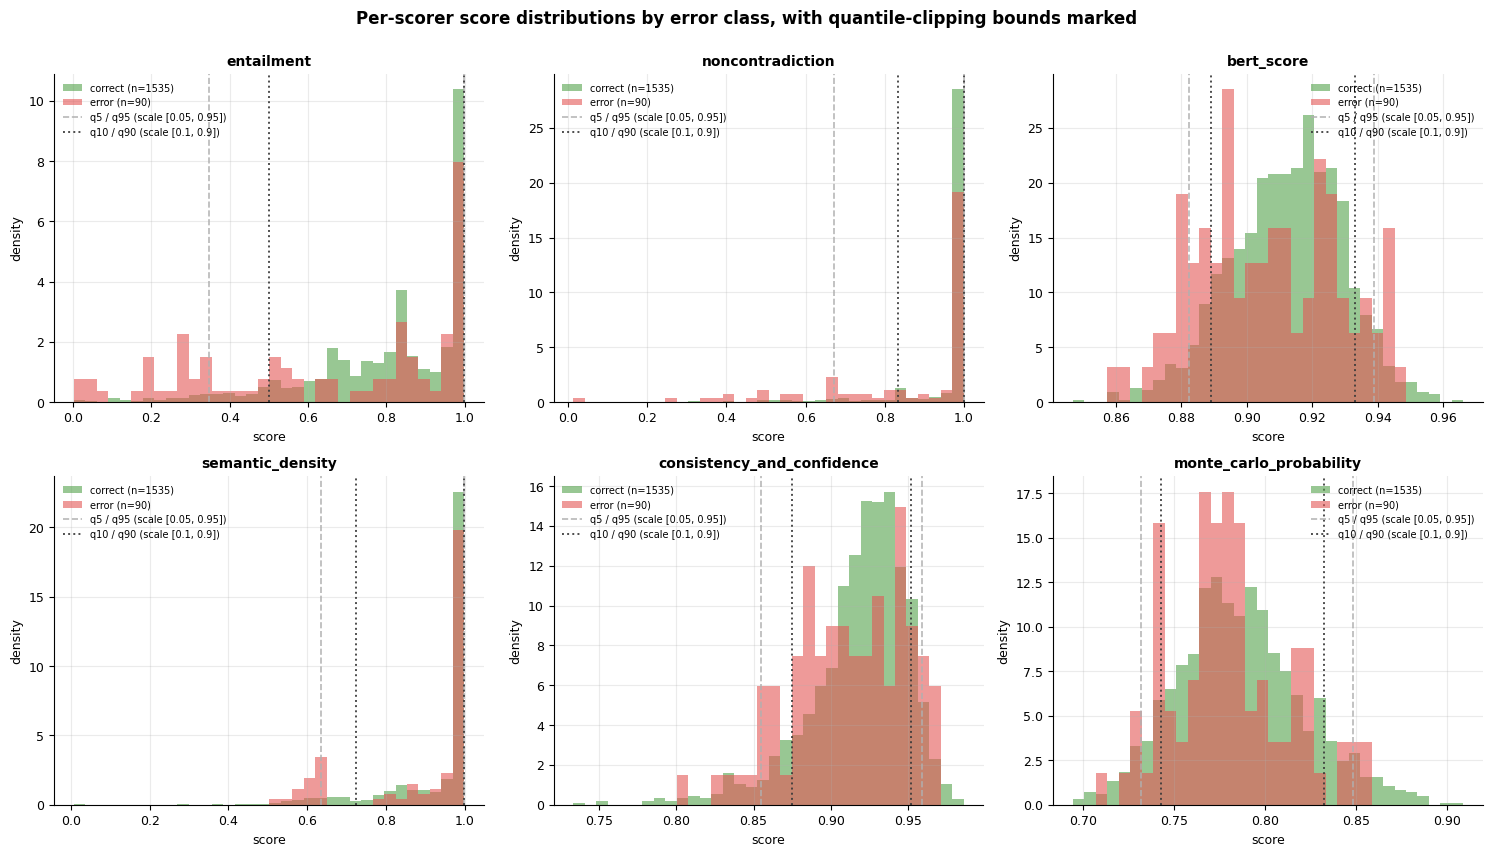


Interpretation:
  -                   entailment: correct mean=0.803, error mean=0.650  (delta=+0.153)  q10-q90 span=0.497
  -             noncontradiction: correct mean=0.959, error mean=0.848  (delta=+0.111)  q10-q90 span=0.167
  -                   bert_score: correct mean=0.912, error mean=0.906  (delta=+0.006)  q10-q90 span=0.044
  -             semantic_density: correct mean=0.928, error mean=0.893  (delta=+0.036)  q10-q90 span=0.274
  -   consistency_and_confidence: correct mean=0.918, error mean=0.911  (delta=+0.007)  q10-q90 span=0.077
  -      monte_carlo_probability: correct mean=0.786, error mean=0.780  (delta=+0.006)  q10-q90 span=0.090

Most scorers have correct-vs-error means within ~0.1 of each other and live on the high end of [0, 1]. That compression is exactly what makes soft-OR saturate without scaling, and what aggressive clipping to [q0.1, q0.9] undoes.


In [12]:
# Per-scorer range / distribution diagnostic.
# Self-contained so it runs after a kernel restart.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from calibration_helpers import load_one_ensemble

_g = globals()
TARGET_BASE_MODEL = _g.get("TARGET_BASE_MODEL", "GPT20B")
ENSEMBLE_IDS = _g.get("ENSEMBLE_IDS", [1, 2, 3, 4, 5])

SCORERS_FOR_RANGES = [
    "entailment",
    "noncontradiction",
    "bert_score",
    "semantic_density",
    "consistency_and_confidence",
    "monte_carlo_probability",
]

dfs = [
    load_one_ensemble(DATA_DIR, eid, methods=SCORERS_FOR_RANGES, target_base_model=TARGET_BASE_MODEL)
    for eid in ENSEMBLE_IDS
]
pooled = pd.concat(dfs, ignore_index=True)

# ---- Ranges table: percentiles per scorer, overall and by error class ----
pct_levels = [0, 5, 10, 25, 50, 75, 90, 95, 100]
rows = []
for scorer in SCORERS_FOR_RANGES:
    s_all = pooled[scorer].dropna().to_numpy()
    s_corr = pooled.loc[pooled["error_label"] == 0, scorer].dropna().to_numpy()
    s_err = pooled.loc[pooled["error_label"] == 1, scorer].dropna().to_numpy()
    row = {
        "scorer": scorer,
        "n_total": len(s_all),
        "n_correct": len(s_corr),
        "n_error": len(s_err),
        "mean_correct": float(s_corr.mean()) if len(s_corr) else np.nan,
        "mean_error": float(s_err.mean()) if len(s_err) else np.nan,
    }
    for p in pct_levels:
        row[f"q{p:02d}"] = float(np.percentile(s_all, p))
    rows.append(row)

ranges_df = pd.DataFrame(rows).round(4)
print("Per-scorer percentiles (pooled across 5 ensembles). "
      "`mean_correct`/`mean_error` are class means:")
display(ranges_df[["scorer", "n_total", "n_correct", "n_error",
                   "mean_correct", "mean_error",
                   "q00", "q05", "q10", "q25", "q50", "q75", "q90", "q95", "q100"]])

# ---- Plots: histograms by class with quantile cutoffs ----
rc = {
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.titleweight": "semibold",
    "legend.frameon": False,
}

COLOR_CORRECT = "#54A24B"
COLOR_ERROR = "#E45756"
COLOR_CUT_TIGHT = "#B0B0B0"
COLOR_CUT_AGGRESSIVE = "#3A3A3A"

with plt.rc_context(rc):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
    axes = axes.flatten()

    for i, scorer in enumerate(SCORERS_FOR_RANGES):
        ax = axes[i]
        s_corr = pooled.loc[pooled["error_label"] == 0, scorer].dropna().to_numpy()
        s_err = pooled.loc[pooled["error_label"] == 1, scorer].dropna().to_numpy()
        s_all = pooled[scorer].dropna().to_numpy()

        lo, hi = float(np.min(s_all)), float(np.max(s_all))
        bins = np.linspace(lo, hi, 35)

        ax.hist(s_corr, bins=bins, alpha=0.6, color=COLOR_CORRECT, density=True,
                label=f"correct (n={len(s_corr)})")
        ax.hist(s_err, bins=bins, alpha=0.6, color=COLOR_ERROR, density=True,
                label=f"error (n={len(s_err)})")

        q05 = np.percentile(s_all, 5)
        q95 = np.percentile(s_all, 95)
        q10 = np.percentile(s_all, 10)
        q90 = np.percentile(s_all, 90)

        ax.axvline(q05, color=COLOR_CUT_TIGHT, ls="--", lw=1.2, alpha=0.9)
        ax.axvline(q95, color=COLOR_CUT_TIGHT, ls="--", lw=1.2, alpha=0.9,
                   label="q5 / q95 (scale [0.05, 0.95])")
        ax.axvline(q10, color=COLOR_CUT_AGGRESSIVE, ls=":", lw=1.4, alpha=0.9)
        ax.axvline(q90, color=COLOR_CUT_AGGRESSIVE, ls=":", lw=1.4, alpha=0.9,
                   label="q10 / q90 (scale [0.1, 0.9])")

        ax.set_title(scorer)
        ax.set_xlabel("score")
        ax.set_ylabel("density")
        ax.legend(fontsize=7, loc="best")

    fig.suptitle(
        "Per-scorer score distributions by error class, "
        "with quantile-clipping bounds marked",
        fontsize=12, fontweight="semibold", y=1.00,
    )
    plt.tight_layout()
    plt.show()

# ---- One-paragraph narrative summary (thesis-style) ----
narrative_lines = []
for _, row in ranges_df.iterrows():
    narrative_lines.append(
        f"  - {row['scorer']:>28s}: correct mean={row['mean_correct']:.3f}, "
        f"error mean={row['mean_error']:.3f}  "
        f"(delta={row['mean_correct']-row['mean_error']:+.3f})  "
        f"q10-q90 span={row['q90']-row['q10']:.3f}"
    )
print(
    "\nInterpretation:\n"
    + "\n".join(narrative_lines)
    + "\n\nMost scorers have correct-vs-error means within ~0.1 of each "
      "other and live on the high end of [0, 1]. That compression is exactly "
      "what makes soft-OR saturate without scaling, and what aggressive "
      "clipping to [q0.1, q0.9] undoes."
)


These plots show the raw score distributions for each scorer, split by whether GPT20B was correct or wrong. Green is correct answers, red is model errors. The vertical lines mark quantile clipping bounds: q05/q95 and q10/q90.

The main pattern is that most scorers are highly compressed near the upper end of the score range. This is expected because the model is usually correct, so many answer sets look confident or internally consistent. However, this compression also means that raw scores are not directly suitable for soft-OR aggregation: if many scores are already close to 1, soft-OR saturates and loses resolution.

`entailment` is the clearest individual signal. Correct cases have a higher mean score than error cases, with the largest separation (`delta = +0.153`). The red error distribution also has more mass at lower scores, suggesting that wrong answers are often less mutually entailing.

`noncontradiction` also separates correct from wrong cases, though less strongly than entailment (`delta = +0.111`). Its distribution is extremely concentrated near 1.0, so quantile scaling is especially important; otherwise most examples would look almost identical.

`semantic_density` provides a weaker but still visible signal (`delta = +0.036`). It captures whether sampled answers cluster semantically. The separation is smaller, but it can still add information when combined with entailment and noncontradiction.

`bert_score`, `consistency_and_confidence`, and `monte_carlo_probability` show almost no separation between correct and error cases. Their class means differ by less than 0.01, so they are difficult to defend as primary error-detection signals in the final calibration.

Overall, the diagnostic supports three decisions used later in the notebook:

1. Scores should be quantile-scaled before aggregation because several scorers are compressed near 1.0.
2. `entailment` and `noncontradiction` are the strongest blackbox signals.
3. `bert_score` should be excluded from the final grid search because it barely distinguishes correct from wrong answers in this dataset.


### Final calibration

For the 3 best scorers `entailment`, `noncontradiction`, `semantic_density` in this time 10 sample runs we search for best combination with a recall of at least 0.7 and f2 as an objective.

For each subset:
- Orientation and per-scorer scaling bounds are learned on the pooled 10 ensembles using global `[q05, q95]` scaling.
- Scorer combinations are evaluated first with plain `soft_or` check-to-test aggregation.
- The threshold is then chosen from the full `THRESHOLDS` sweep by maximizing F2 subject to mean recall >= `RECALL_FLOOR` (`0.70`).
- Only after the best combination and threshold are selected, the gated floor is derived as `gate = threshold - MIN_THRESHOLD_GATE_GAP` and used for the downstream gated UE workflow to reduce FPs.


In [13]:
ALL_SCORERS = [
    "entailment",
    "noncontradiction",
    "semantic_density",
]

PRIMARY_THRESHOLD_METRIC = "f2"
RECALL_FLOOR = 0.7
FLAG_COUNT_MIN = 10
FLAG_COUNT_MAX = None
MIN_THRESHOLD = MIN_THRESHOLD_GATE_GAP

ORIGINAL_ENSEMBLE_IDS = [1, 2, 3, 4, 5]
COMBINED_ENSEMBLE_IDS = [1, 2, 3, 4, 5]
COMBINED_ENSEMBLE_FILES = {
    1: "GPT20_Ensemble_all_v1.csv",
    2: "GPT20_Ensemble_all_v2.csv",
    3: "GPT20_Ensemble_all_v3.csv",
    4: "GPT20_Ensemble_all_v4.csv",
    5: "GPT20_Ensemble_all_v5.csv",
}


def load_combined_ensemble_for_search(data_dir, ensemble_id, methods, target_base_model=None, ensemble_label=None):
    path = Path(data_dir) / COMBINED_ENSEMBLE_FILES[ensemble_id]
    needed_cols = [*CHECK_KEY, "match", *methods]
    if target_base_model is not None:
        needed_cols.append("base_model")

    df = pd.read_csv(path, usecols=needed_cols)
    if target_base_model is not None and "base_model" in df.columns:
        df = df[df["base_model"] == target_base_model].copy()

    df = add_model_error_target(df, "match")
    require_constant_within_tests(df, "label", f"combined ensemble {ensemble_id}")
    df["ensemble"] = ensemble_id if ensemble_label is None else ensemble_label
    return df


ensemble_dfs = [
    load_one_ensemble(DATA_DIR, eid, methods=ALL_SCORERS, target_base_model=TARGET_BASE_MODEL)
    for eid in ORIGINAL_ENSEMBLE_IDS
]
ensemble_dfs.extend(
    load_combined_ensemble_for_search(
        DATA_DIR,
        eid,
        methods=ALL_SCORERS,
        target_base_model=TARGET_BASE_MODEL,
        ensemble_label=len(ORIGINAL_ENSEMBLE_IDS) + i,
    )
    for i, eid in enumerate(COMBINED_ENSEMBLE_IDS, start=1)
)


def gate_for_threshold(threshold):
    return max(0.0, round(float(threshold) - MIN_THRESHOLD_GATE_GAP, 3))


def fit_soft_or_params(train_dfs, methods):
    train_all = pd.concat(train_dfs, ignore_index=True)
    return pd.DataFrame([
        learn_global_orientation_and_bounds(
            train_all, method, q_low=PROD_Q_LOW, q_high=PROD_Q_HIGH,
            agg_fn=soft_or, scale=SCALE,
        )
        for method in methods
    ])


def evaluate_params_at(test_df, params, methods, threshold, agg_fn):
    test_work = build_test_work(test_df, params, methods, agg_fn=agg_fn, scale=SCALE)
    y_test = test_work["error_label"].astype(int).to_numpy()
    scores = test_work["test_ensemble_error_score"].to_numpy(dtype=float)
    metrics = threshold_metrics(y_test, scores, threshold)
    metrics["ap_error"] = float(average_precision_score(y_test, scores))
    metrics["ensemble"] = test_df["ensemble"].iloc[0]
    return metrics


def summarize_thresholds(train_dfs, params, methods, agg_fn):
    rows = []
    for df in train_dfs:
        test_work = build_test_work(df, params, methods, agg_fn=agg_fn, scale=SCALE)
        y_test = test_work["error_label"].astype(int).to_numpy()
        scores = test_work["test_ensemble_error_score"].to_numpy(dtype=float)
        for tau in THRESHOLDS:
            if tau < MIN_THRESHOLD:
                continue
            row = threshold_metrics(y_test, scores, tau)
            row["ensemble"] = df["ensemble"].iloc[0]
            rows.append(row)
    return per_threshold_summary(pd.DataFrame(rows))


def pick_f2_threshold(summary):
    viable_mask = (
        (summary["recall_error_mean"] >= RECALL_FLOOR)
        & (summary["n_flagged_mean"] >= FLAG_COUNT_MIN)
    )
    if FLAG_COUNT_MAX is not None:
        viable_mask &= summary["n_flagged_mean"] <= FLAG_COUNT_MAX
    viable = summary[viable_mask].copy()
    if viable.empty:
        return None
    return viable.sort_values(
        ["f2_error_mean", "fp_error_mean", "n_flagged_mean"],
        ascending=[False, True, True],
    ).iloc[0]


def score_subset(methods):
    soft_params = fit_soft_or_params(ensemble_dfs, methods)
    soft_summary = summarize_thresholds(ensemble_dfs, soft_params, methods, soft_or)
    chosen = pick_f2_threshold(soft_summary)
    if chosen is None:
        return {
            "methods": "+".join(methods),
            "k": len(methods),
            "feasible": False,
            "threshold": np.nan,
            "gate_floor": np.nan,
            "precision_error": np.nan,
            "recall_error": np.nan,
            "f1_error": np.nan,
            "f2_error": np.nan,
            "ap_error": np.nan,
            "n_flagged": np.nan,
            "tp_error": np.nan,
            "fp_error": np.nan,
            "fn_error": np.nan,
        }

    tau = float(chosen["threshold"])
    gate_floor = gate_for_threshold(tau)
    gated_agg = make_gated_soft_or(gate_floor)

    train_all = pd.concat(ensemble_dfs, ignore_index=True)
    gated_params = pd.DataFrame([
        learn_global_orientation_and_bounds(
            train_all, method, q_low=PROD_Q_LOW, q_high=PROD_Q_HIGH,
            agg_fn=gated_agg, scale=SCALE,
        )
        for method in methods
    ])
    per_gated = pd.DataFrame([
        evaluate_params_at(df, gated_params, methods, tau, gated_agg)
        for df in ensemble_dfs
    ])

    row = {
        "methods": "+".join(methods),
        "k": len(methods),
        "threshold": tau,
        "gate_floor": gate_floor,
        "precision_error": per_gated["precision_error"].mean(),
        "recall_error": per_gated["recall_error"].mean(),
        "f1_error": per_gated["f1_error"].mean(),
        "f2_error": per_gated["f2_error"].mean(),
        "ap_error": per_gated["ap_error"].mean(),
        "n_flagged": per_gated["n_flagged"].mean(),
        "tp_error": per_gated["tp_error"].mean(),
        "fp_error": per_gated["fp_error"].mean(),
        "fn_error": per_gated["fn_error"].mean(),
    }
    row["feasible"] = (
        (row["recall_error"] >= RECALL_FLOOR)
        and (row["n_flagged"] >= FLAG_COUNT_MIN)
        and (FLAG_COUNT_MAX is None or row["n_flagged"] <= FLAG_COUNT_MAX)
    )
    return row


def score_subset_loo(methods):
    """Leave-one-ensemble-out evaluation for one scorer subset.

    For each held-out ensemble, fit orientation/scaling and choose tau on the
    other nine ensembles, derive gate=tau-0.10, then evaluate only the held-out
    ensemble. This reports stability; the production config is still selected
    by the full 10-ensemble search above.
    """
    fold_rows = []
    failed_folds = []

    for holdout_idx, test_df in enumerate(ensemble_dfs):
        train_dfs = [df for i, df in enumerate(ensemble_dfs) if i != holdout_idx]

        soft_params = fit_soft_or_params(train_dfs, methods)
        soft_summary = summarize_thresholds(train_dfs, soft_params, methods, soft_or)
        chosen = pick_f2_threshold(soft_summary)
        if chosen is None:
            failed_folds.append(int(test_df["ensemble"].iloc[0]))
            continue

        tau = float(chosen["threshold"])
        gate_floor = gate_for_threshold(tau)
        gated_agg = make_gated_soft_or(gate_floor)

        train_all = pd.concat(train_dfs, ignore_index=True)
        gated_params = pd.DataFrame([
            learn_global_orientation_and_bounds(
                train_all, method, q_low=PROD_Q_LOW, q_high=PROD_Q_HIGH,
                agg_fn=gated_agg, scale=SCALE,
            )
            for method in methods
        ])
        fold = evaluate_params_at(test_df, gated_params, methods, tau, gated_agg)
        fold["threshold"] = tau
        fold["gate_floor"] = gate_floor
        fold_rows.append(fold)

    base = {
        "methods": "+".join(methods),
        "k": len(methods),
        "loo_valid_folds": len(fold_rows),
        "loo_failed_folds": len(failed_folds),
        "loo_failed_ensembles": failed_folds,
    }
    if not fold_rows:
        return {
            **base,
            "loo_feasible": False,
            "loo_threshold_mean": np.nan,
            "loo_gate_floor_mean": np.nan,
            "loo_precision_error": np.nan,
            "loo_recall_error": np.nan,
            "loo_f1_error": np.nan,
            "loo_f2_error": np.nan,
            "loo_ap_error": np.nan,
            "loo_n_flagged": np.nan,
            "loo_tp_error": np.nan,
            "loo_fp_error": np.nan,
            "loo_fn_error": np.nan,
        }

    folds = pd.DataFrame(fold_rows)
    row = {
        **base,
        "loo_threshold_mean": folds["threshold"].mean(),
        "loo_threshold_min": folds["threshold"].min(),
        "loo_threshold_max": folds["threshold"].max(),
        "loo_gate_floor_mean": folds["gate_floor"].mean(),
        "loo_precision_error": folds["precision_error"].mean(),
        "loo_recall_error": folds["recall_error"].mean(),
        "loo_f1_error": folds["f1_error"].mean(),
        "loo_f2_error": folds["f2_error"].mean(),
        "loo_ap_error": folds["ap_error"].mean(),
        "loo_n_flagged": folds["n_flagged"].mean(),
        "loo_tp_error": folds["tp_error"].mean(),
        "loo_fp_error": folds["fp_error"].mean(),
        "loo_fn_error": folds["fn_error"].mean(),
    }
    row["loo_feasible"] = (
        (row["loo_failed_folds"] == 0)
        and (row["loo_recall_error"] >= RECALL_FLOOR)
        and (row["loo_n_flagged"] >= FLAG_COUNT_MIN)
        and (FLAG_COUNT_MAX is None or row["loo_n_flagged"] <= FLAG_COUNT_MAX)
    )
    return row


all_subsets = [
    list(combo)
    for k in range(1, len(ALL_SCORERS) + 1)
    for combo in itertools.combinations(ALL_SCORERS, k)
]

subset_results_all = pd.DataFrame([score_subset(subset) for subset in all_subsets])
loo_results_all = pd.DataFrame([score_subset_loo(subset) for subset in all_subsets])
feasible = subset_results_all[subset_results_all["feasible"]].copy()
infeasible = subset_results_all[~subset_results_all["feasible"]].copy()

_sort_col = f"{PRIMARY_THRESHOLD_METRIC}_error"
subset_results = feasible.sort_values(
    [_sort_col, "fp_error", "n_flagged", "precision_error"],
    ascending=[False, True, True, False],
).reset_index(drop=True)

flag_constraint = f"flags >= {FLAG_COUNT_MIN}"
if FLAG_COUNT_MAX is not None:
    flag_constraint += f" and <= {FLAG_COUNT_MAX}"
print(
    f"10-ensemble subset search -> F2 threshold -> gate (scale={SCALE}, q_low={PROD_Q_LOW}, q_high={PROD_Q_HIGH}, "
    f"recall_floor={RECALL_FLOOR:.2f}, {flag_constraint}, gate=tau-{MIN_THRESHOLD_GATE_GAP:.2f})"
)
print(f"Total subsets: {len(subset_results_all)}   feasible: {len(subset_results)}   infeasible: {len(infeasible)}")

if subset_results.empty:
    raise RuntimeError(
        f"No subset is feasible (recall >= {RECALL_FLOOR:.2f}, {flag_constraint}). "
        "Relax a constraint or widen the threshold grid."
    )

print(f"\nTop 10 feasible subsets by gated {PRIMARY_THRESHOLD_METRIC.upper()} after threshold-derived gate:")
display(subset_results.head(10))

loo_results = (
    loo_results_all
    .sort_values(["loo_feasible", "loo_f2_error", "loo_fp_error", "loo_n_flagged", "loo_precision_error"],
                 ascending=[False, False, True, True, False])
    .reset_index(drop=True)
)
print(f"\nTop 10 subsets by LOO gated {PRIMARY_THRESHOLD_METRIC.upper()} after threshold-derived gate:")
display(loo_results.head(10))

best = subset_results.iloc[0]
BEST_METHODS = best["methods"].split("+")
BEST_GATE_FLOOR = float(best["gate_floor"])
BEST_THRESHOLD = float(best["threshold"])

GATED_FLOOR = BEST_GATE_FLOOR
CHECK_TO_TEST_AGG = make_gated_soft_or(GATED_FLOOR)
CHECK_TO_TEST_AGG_NAME = getattr(CHECK_TO_TEST_AGG, "__name__", repr(CHECK_TO_TEST_AGG))

loo_best_match = loo_results_all[loo_results_all["methods"].eq(best["methods"])]
if not loo_best_match.empty:
    print("\nLOO evaluation for selected winner:")
    display(loo_best_match.round(3))

print(
    f"\nWinner: {best['methods']}  "
    f"gate={BEST_GATE_FLOOR:.3f}  "
    f"tau={BEST_THRESHOLD:.3f}  "
    f"F1={best['f1_error']:.3f}  "
    f"F2={best['f2_error']:.3f}  "
    f"P={best['precision_error']:.3f}  "
    f"R={best['recall_error']:.3f}  "
    f"AP={best['ap_error']:.3f}  "
    f"flagged={best['n_flagged']:.1f}  "
    f"TP={best['tp_error']:.1f}  FP={best['fp_error']:.1f}  FN={best['fn_error']:.1f}"
)

# Fit reusable gated params for downstream cells.
_train_all = pd.concat(ensemble_dfs, ignore_index=True)
global_params = pd.DataFrame([
    learn_global_orientation_and_bounds(
        _train_all, method, q_low=PROD_Q_LOW, q_high=PROD_Q_HIGH,
        agg_fn=CHECK_TO_TEST_AGG, scale=SCALE,
    )
    for method in BEST_METHODS
])
in_sample_threshold = BEST_THRESHOLD
in_sample_eval = pd.DataFrame([
    evaluate_params_at(df, global_params, BEST_METHODS, in_sample_threshold, CHECK_TO_TEST_AGG)
    for df in ensemble_dfs
])

in_sample_summary_row = pd.DataFrame({
    "metric": ["gate_floor", "threshold", "precision_error", "recall_error", "f1_error", "f2_error",
               "n_flagged", "tp_error", "fp_error", "fn_error"],
    "in_sample_mean": [
        BEST_GATE_FLOOR,
        in_sample_threshold,
        in_sample_eval["precision_error"].mean(),
        in_sample_eval["recall_error"].mean(),
        in_sample_eval["f1_error"].mean(),
        in_sample_eval["f2_error"].mean(),
        in_sample_eval["n_flagged"].mean(),
        in_sample_eval["tp_error"].mean(),
        in_sample_eval["fp_error"].mean(),
        in_sample_eval["fn_error"].mean(),
    ],
})
print("\nIn-sample mean across 10 ensembles:")
display(in_sample_summary_row)

METHODS = BEST_METHODS



10-ensemble subset search -> F2 threshold -> gate (scale=True, q_low=0.05, q_high=0.95, recall_floor=0.70, flags >= 10, gate=tau-0.10)
Total subsets: 7   feasible: 3   infeasible: 4

Top 10 feasible subsets by gated F2 after threshold-derived gate:


,methods,k,threshold,gate_floor,precision_error,recall_error,f1_error,f2_error,ap_error,n_flagged,tp_error,fp_error,fn_error,feasible
0,entailment+noncontradiction+semantic_density,3,0.335,0.235,0.132458,0.736893,0.224204,0.384154,0.207301,71.0,9.4,61.6,3.3,True
1,noncontradiction+semantic_density,2,0.230,0.130,0.116480,0.703711,0.199586,0.349399,0.178264,77.2,9.0,68.2,3.7,True
2,entailment+semantic_density,2,0.325,0.225,0.109634,0.752369,0.191165,0.345502,0.158631,87.4,9.6,77.8,3.1,True



Top 10 subsets by LOO gated F2 after threshold-derived gate:


,methods,k,loo_valid_folds,loo_failed_folds,loo_failed_ensembles,loo_threshold_mean,loo_threshold_min,loo_threshold_max,loo_gate_floor_mean,loo_precision_error,loo_recall_error,loo_f1_error,loo_f2_error,loo_ap_error,loo_n_flagged,loo_tp_error,loo_fp_error,loo_fn_error,loo_feasible
0,entailment+noncontradiction+semantic_density,3,10,0,[],0.3430,0.320,0.390,0.2430,0.131217,0.710378,0.221109,0.376001,0.207536,68.5,9.1,59.4,3.6,True
1,entailment+semantic_density,2,10,0,[],0.3270,0.325,0.335,0.2270,0.107606,0.736985,0.187575,0.338838,0.159169,87.0,9.4,77.6,3.3,True
2,entailment+noncontradiction,2,10,0,[],0.3350,0.325,0.345,0.2350,0.132833,0.685080,0.222145,0.372921,0.231339,65.7,8.7,57.0,4.0,False
3,noncontradiction+semantic_density,2,10,0,[],0.2355,0.210,0.290,0.1355,0.116726,0.694620,0.199632,0.348223,0.177765,75.6,8.9,66.7,3.8,False
4,entailment,1,10,0,[],0.4700,0.450,0.535,0.3700,0.108881,0.660604,0.186179,0.325513,0.198416,76.9,8.4,68.5,4.3,False
5,noncontradiction,1,0,10,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
6,semantic_density,1,0,10,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False



LOO evaluation for selected winner:


,methods,k,loo_valid_folds,loo_failed_folds,loo_failed_ensembles,loo_threshold_mean,loo_threshold_min,loo_threshold_max,loo_gate_floor_mean,loo_precision_error,loo_recall_error,loo_f1_error,loo_f2_error,loo_ap_error,loo_n_flagged,loo_tp_error,loo_fp_error,loo_fn_error,loo_feasible
6,entailment+noncontradiction+semantic_density,3,10,0,[],0.343,0.32,0.39,0.243,0.131,0.71,0.221,0.376,0.208,68.5,9.1,59.4,3.6,True



Winner: entailment+noncontradiction+semantic_density  gate=0.235  tau=0.335  F1=0.224  F2=0.384  P=0.132  R=0.737  AP=0.207  flagged=71.0  TP=9.4  FP=61.6  FN=3.3

In-sample mean across 10 ensembles:


,metric,in_sample_mean
0,gate_floor,0.235000
1,threshold,0.335000
2,precision_error,0.132458
3,recall_error,0.736893
4,f1_error,0.224204
5,f2_error,0.384154
6,n_flagged,71.000000
7,tp_error,9.400000
8,fp_error,61.600000
9,fn_error,3.300000


### Per-project view

One ensemble is 195 tests spread across 13 projects x 15 tests. The numbers above
are per-ensemble totals, so they don't map directly to what a single project
upload looks like. The table and plot below re-express the winner's operating
point at the project level: for a typical upload with 15 tests, how many flags,
true positives and false positives should the reviewer expect, and how much does
that vary by project?


Per-project behaviour for winner: entailment+noncontradiction+semantic_density | tau=0.335 | overall catch rate=0.74


,metric,value
0,avg flagged per project/upload,5.462
1,avg TP per project,0.723
2,avg FP per project,4.738
3,avg FN per project,0.254
4,avg errors present per project,0.977
5,overall catch rate,0.740


,project_id,uploads,n_tests,errors_present,flagged,tp,fp,fn,tn,catch_rate,precision
0,9583,10,15.0,0.1,5.5,0.1,5.4,0.0,9.5,1.000,0.033
1,169402,10,15.0,0.2,4.9,0.2,4.7,0.0,10.1,1.000,0.053
2,189879,10,15.0,1.0,5.6,0.0,5.6,1.0,8.4,0.000,0.000
3,190944,10,15.0,2.7,4.6,2.2,2.4,0.5,9.9,0.833,0.560
4,191846,10,15.0,0.0,5.3,0.0,5.3,0.0,9.7,NaN,0.000
5,192494,10,15.0,0.4,4.7,0.4,4.3,0.0,10.3,1.000,0.093
6,196565,10,15.0,1.9,5.8,1.6,4.2,0.3,8.9,0.883,0.278
7,205270,10,15.0,2.6,6.1,2.0,4.1,0.6,8.3,0.733,0.310
8,221633,10,15.0,1.0,6.4,0.5,5.9,0.5,8.1,0.500,0.093
9,229691,10,15.0,0.6,4.2,0.6,3.6,0.0,10.8,1.000,0.200


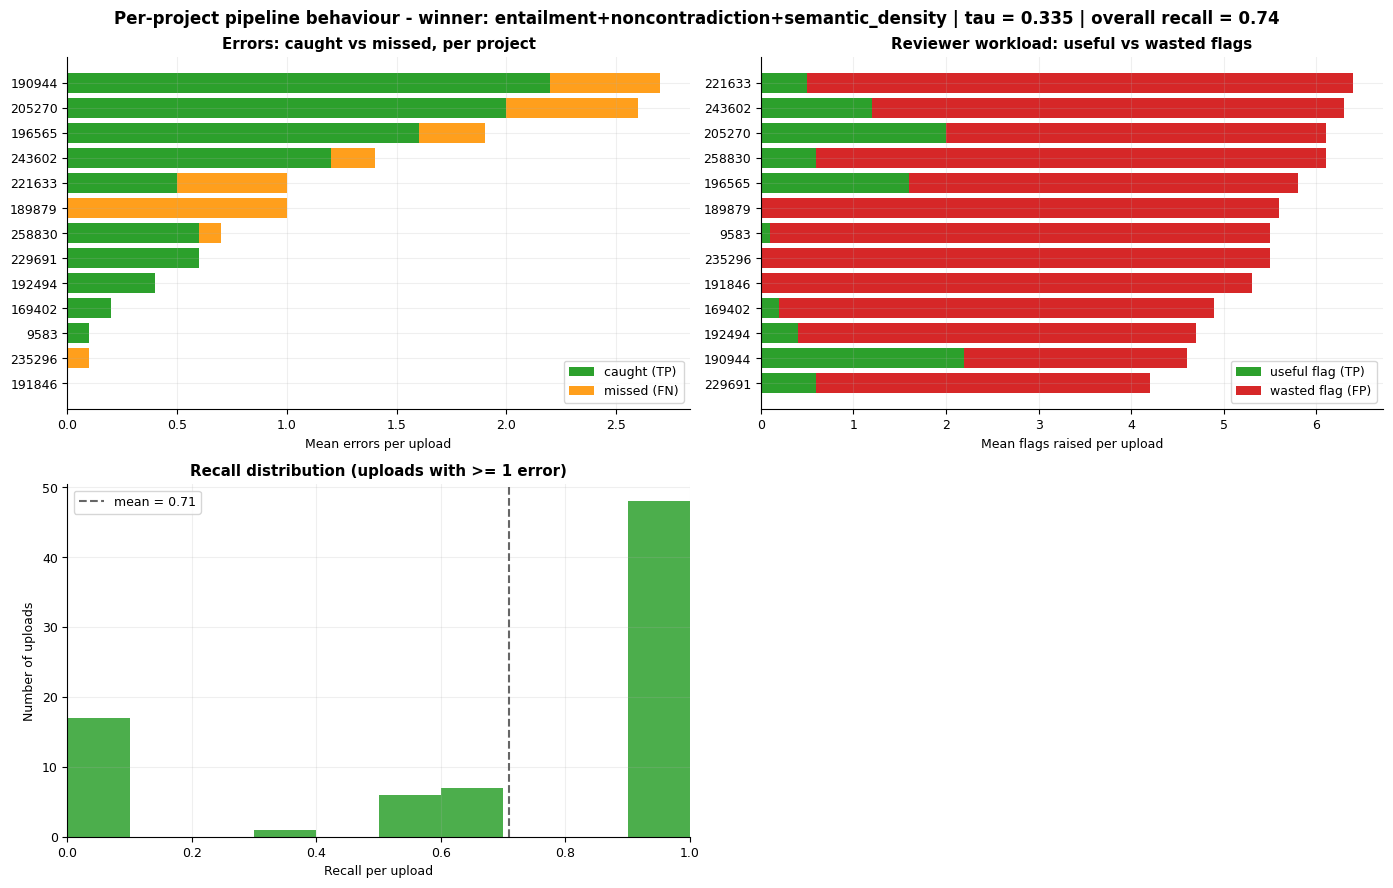

In [26]:
# Per-project pipeline behaviour for the selected winner.
# Requires: ensemble_dfs, global_params, METHODS, CHECK_TO_TEST_AGG, SCALE,
# and either BEST_THRESHOLD or in_sample_threshold.

TAU = float(globals().get("BEST_THRESHOLD", globals().get("in_sample_threshold")))

project_rows = []

for df in ensemble_dfs:
    tw = build_test_work(
        df,
        global_params,
        METHODS,
        agg_fn=CHECK_TO_TEST_AGG,
        scale=SCALE,
    ).copy()

    tw["pred_error"] = (tw["test_ensemble_error_score"] >= TAU).astype(int)
    tw["ensemble"] = df["ensemble"].iloc[0]

    for (ensemble, project_id), g in tw.groupby(["ensemble", "project_id"], dropna=False):
        y = g["error_label"].astype(int)
        pred = g["pred_error"].astype(int)

        tp = int(((pred == 1) & (y == 1)).sum())
        fp = int(((pred == 1) & (y == 0)).sum())
        fn = int(((pred == 0) & (y == 1)).sum())
        tn = int(((pred == 0) & (y == 0)).sum())

        project_rows.append({
            "ensemble": ensemble,
            "project_id": project_id,
            "n_tests": int(len(g)),
            "errors_present": int(y.sum()),
            "flagged": int(pred.sum()),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
            "catch_rate": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            "precision": tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        })

project_upload_df = pd.DataFrame(project_rows)

project_mean = (
    project_upload_df
    .groupby("project_id", as_index=False)
    .agg(
        uploads=("ensemble", "nunique"),
        n_tests=("n_tests", "mean"),
        errors_present=("errors_present", "mean"),
        flagged=("flagged", "mean"),
        tp=("tp", "mean"),
        fp=("fp", "mean"),
        fn=("fn", "mean"),
        tn=("tn", "mean"),
        catch_rate=("catch_rate", "mean"),
        precision=("precision", "mean"),
    )
)

overall_catch_rate = (
    project_upload_df["tp"].sum()
    / max(project_upload_df["tp"].sum() + project_upload_df["fn"].sum(), 1)
)

summary = pd.DataFrame({
    "metric": [
        "avg flagged per project/upload",
        "avg TP per project",
        "avg FP per project",
        "avg FN per project",
        "avg errors present per project",
        "overall catch rate",
    ],
    "value": [
        project_upload_df["flagged"].mean(),
        project_upload_df["tp"].mean(),
        project_upload_df["fp"].mean(),
        project_upload_df["fn"].mean(),
        project_upload_df["errors_present"].mean(),
        overall_catch_rate,
    ],
})

print(
    f"Per-project behaviour for winner: {'+'.join(METHODS)} | "
    f"tau={TAU:.3f} | overall catch rate={overall_catch_rate:.2f}"
)
display(summary.round(3))
display(project_mean.round(3))

# ---- Plots: first three only ----
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "font.size": 9,
})

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax1, ax2, ax3, ax_unused = axes.flatten()
ax_unused.axis("off")

# 1. Errors caught vs missed, per project
err_plot = project_mean.sort_values(["errors_present", "tp"], ascending=True)
ypos = np.arange(len(err_plot))

ax1.barh(ypos, err_plot["tp"], color="#2CA02C", label="caught (TP)")
ax1.barh(ypos, err_plot["fn"], left=err_plot["tp"], color="#FF9F1C", label="missed (FN)")
ax1.set_yticks(ypos)
ax1.set_yticklabels(err_plot["project_id"])
ax1.set_xlabel("Mean errors per upload")
ax1.set_title("Errors: caught vs missed, per project", fontweight="semibold")
ax1.legend(loc="lower right")

# 2. Reviewer workload: useful vs wasted flags
flag_plot = project_mean.sort_values(["flagged", "tp"], ascending=True)
ypos = np.arange(len(flag_plot))

ax2.barh(ypos, flag_plot["tp"], color="#2CA02C", label="useful flag (TP)")
ax2.barh(ypos, flag_plot["fp"], left=flag_plot["tp"], color="#D62728", label="wasted flag (FP)")
ax2.set_yticks(ypos)
ax2.set_yticklabels(flag_plot["project_id"])
ax2.set_xlabel("Mean flags raised per upload")
ax2.set_title("Reviewer workload: useful vs wasted flags", fontweight="semibold")
ax2.legend(loc="lower right")

# 3. Catch-rate distribution for project uploads with at least one error
catch_rates = project_upload_df.loc[
    project_upload_df["errors_present"] > 0,
    "catch_rate",
].dropna()

ax3.hist(catch_rates, bins=np.linspace(0, 1, 11), color="#2CA02C", alpha=0.85)
ax3.axvline(catch_rates.mean(), color="#666666", linestyle="--", linewidth=1.5,
            label=f"mean = {catch_rates.mean():.2f}")
ax3.set_xlim(0, 1)
ax3.set_xlabel("Recall per upload")
ax3.set_ylabel("Number of uploads")
ax3.set_title("Recall distribution (uploads with >= 1 error)", fontweight="semibold")
ax3.legend(loc="upper left")

fig.suptitle(
    f"Per-project pipeline behaviour - winner: {'+'.join(METHODS)} | "
    f"tau = {TAU:.3f} | overall recall = {overall_catch_rate:.2f}",
    fontsize=12,
    fontweight="semibold",
)

plt.tight_layout()
plt.show()


Catch-rate shape among project uploads with at least one true error:


,group,n_uploads,share_of_error_uploads
0,0% catch,17,0.215
1,partial catch,14,0.177
2,100% catch,48,0.608


0% catch uploads: errors were present, but no true errors were flagged.


,ensemble,project_id,n_tests,errors_present,flagged,tp,fp,fn,catch_rate
7,1,205270,15,2,3,0,3,2,0.0
8,1,221633,15,1,8,0,8,1,0.0
54,5,189879,15,1,8,0,8,1,0.0
67,6,189879,15,1,8,0,8,1,0.0
47,4,221633,15,1,7,0,7,1,0.0
112,9,221633,15,1,7,0,7,1,0.0
119,10,189879,15,1,7,0,7,1,0.0
2,1,189879,15,1,6,0,6,1,0.0
60,5,221633,15,1,6,0,6,1,0.0
28,3,189879,15,1,5,0,5,1,0.0


100% catch uploads: all true errors in the upload were flagged.


,ensemble,project_id,n_tests,errors_present,flagged,tp,fp,fn,catch_rate
68,6,190944,15,3,3,3,0,0,1.0
20,2,205270,15,3,6,3,3,0,1.0
3,1,190944,15,3,7,3,4,0,1.0
16,2,190944,15,3,8,3,5,0,1.0
46,4,205270,15,3,8,3,5,0,1.0
59,5,205270,15,3,8,3,5,0,1.0
85,7,205270,15,3,9,3,6,0,1.0
102,8,243602,15,2,4,2,2,0,1.0
120,10,190944,15,2,4,2,2,0,1.0
29,3,190944,15,2,5,2,3,0,1.0


Missed true-error tests inside the 0% catch uploads:


,ensemble,project_id,test_code,test_ensemble_error_score,error_label,pred_error
0,1,189879,test_inkonsistenz_termin,0.000,1,False
1,1,205270,test_lehrlingsausbildung,0.000,1,False
2,1,205270,test_sachfremde_kriterien,0.319,1,False
3,1,221633,test_falsche_rechtsmittelbelehrung,0.000,1,False
4,1,235296,test_inkonsistenz_termin,0.000,1,False
5,2,189879,test_inkonsistenz_termin,0.000,1,False
6,3,189879,test_inkonsistenz_termin,0.000,1,False
7,3,221633,test_falsche_rechtsmittelbelehrung,0.000,1,False
8,4,189879,test_inkonsistenz_termin,0.000,1,False
9,4,221633,test_falsche_rechtsmittelbelehrung,0.000,1,False


Most common missed test types in 0% catch uploads:


,test_code,n_missed
0,test_inkonsistenz_termin,11
1,test_falsche_rechtsmittelbelehrung,5
2,test_lehrlingsausbildung,1
3,test_sachfremde_kriterien,1


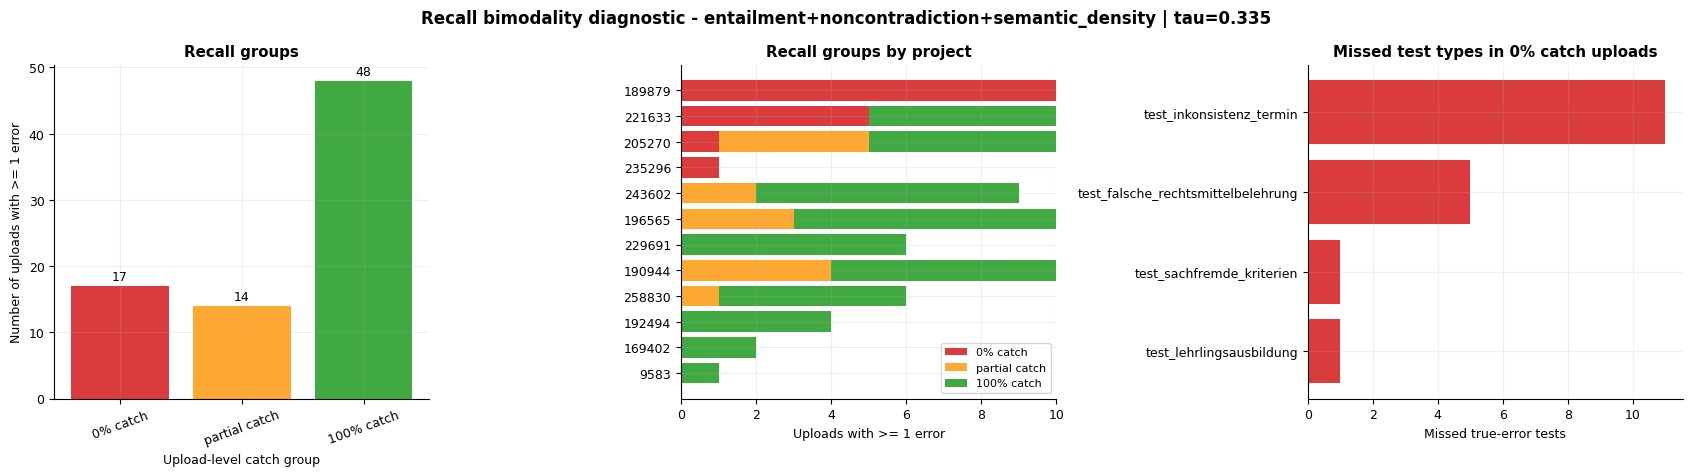

In [28]:
# Diagnose bimodal catch-rate behaviour.
# The histogram mean can hide whether project uploads are either mostly perfect
# or mostly missed. This cell lists those extremes and the missed error tests.

TAU = float(globals().get("BEST_THRESHOLD", globals().get("in_sample_threshold")))

test_rows = []
for df in ensemble_dfs:
    tw = build_test_work(
        df,
        global_params,
        METHODS,
        agg_fn=CHECK_TO_TEST_AGG,
        scale=SCALE,
    ).copy()
    tw["ensemble"] = df["ensemble"].iloc[0]
    tw["pred_error"] = tw["test_ensemble_error_score"] >= TAU
    test_rows.append(tw)

project_test_df = pd.concat(test_rows, ignore_index=True)

error_uploads = project_upload_df[project_upload_df["errors_present"] > 0].copy()
zero_catch_uploads = error_uploads[error_uploads["catch_rate"] == 0].sort_values(
    ["errors_present", "flagged"], ascending=[False, False]
)
perfect_catch_uploads = error_uploads[error_uploads["catch_rate"] == 1].sort_values(
    ["errors_present", "flagged"], ascending=[False, True]
)
partial_catch_uploads = error_uploads[
    (error_uploads["catch_rate"] > 0) & (error_uploads["catch_rate"] < 1)
].sort_values("catch_rate")

catch_shape_summary = pd.DataFrame({
    "group": ["0% catch", "partial catch", "100% catch"],
    "n_uploads": [len(zero_catch_uploads), len(partial_catch_uploads), len(perfect_catch_uploads)],
    "share_of_error_uploads": [
        len(zero_catch_uploads) / max(len(error_uploads), 1),
        len(partial_catch_uploads) / max(len(error_uploads), 1),
        len(perfect_catch_uploads) / max(len(error_uploads), 1),
    ],
})

print("Catch-rate shape among project uploads with at least one true error:")
display(catch_shape_summary.round(3))

print("0% catch uploads: errors were present, but no true errors were flagged.")
display(zero_catch_uploads[[
    "ensemble", "project_id", "n_tests", "errors_present", "flagged", "tp", "fp", "fn", "catch_rate"
]].round(3))

print("100% catch uploads: all true errors in the upload were flagged.")
display(perfect_catch_uploads[[
    "ensemble", "project_id", "n_tests", "errors_present", "flagged", "tp", "fp", "fn", "catch_rate"
]].round(3))

missed_error_tests = project_test_df[
    (project_test_df["error_label"] == 1)
    & (~project_test_df["pred_error"])
].merge(
    zero_catch_uploads[["ensemble", "project_id"]],
    on=["ensemble", "project_id"],
    how="inner",
)

print("Missed true-error tests inside the 0% catch uploads:")
display(missed_error_tests[[
    "ensemble", "project_id", "test_code", "test_ensemble_error_score", "error_label", "pred_error"
]].sort_values(["ensemble", "project_id", "test_code"]).round(3))

print("Most common missed test types in 0% catch uploads:")
display(
    missed_error_tests["test_code"]
    .value_counts()
    .rename_axis("test_code")
    .reset_index(name="n_missed")
)


# ---- Plots for the bimodality diagnostic ----
plot_uploads = error_uploads.copy()
plot_uploads["catch_group"] = np.select(
    [
        plot_uploads["catch_rate"].eq(0),
        plot_uploads["catch_rate"].eq(1),
    ],
    ["0% catch", "100% catch"],
    default="partial catch",
)

catch_group_order = ["0% catch", "partial catch", "100% catch"]
catch_group_colors = {
    "0% catch": "#D62728",
    "partial catch": "#FF9F1C",
    "100% catch": "#2CA02C",
}

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
ax1, ax2, ax3 = axes

# 1. Overall shape: how many error-containing uploads fall into each catch group.
group_counts = (
    plot_uploads["catch_group"]
    .value_counts()
    .reindex(catch_group_order, fill_value=0)
)
ax1.bar(
    group_counts.index,
    group_counts.values,
    color=[catch_group_colors[g] for g in group_counts.index],
    alpha=0.9,
)
ax1.set_title("Recall groups", fontweight="semibold")
ax1.set_ylabel("Number of uploads with >= 1 error")
ax1.set_xlabel("Upload-level catch group")
ax1.tick_params(axis="x", rotation=20)
for x, v in enumerate(group_counts.values):
    ax1.text(x, v + 0.4, str(int(v)), ha="center", va="bottom", fontsize=9)

# 2. Which projects drive 0% vs 100% catch behaviour?
project_catch_counts = (
    plot_uploads
    .pivot_table(
        index="project_id",
        columns="catch_group",
        values="ensemble",
        aggfunc="count",
        fill_value=0,
    )
    .reindex(columns=catch_group_order, fill_value=0)
)
project_catch_counts = project_catch_counts.sort_values(
    ["0% catch", "100% catch"], ascending=[True, True]
)
ypos = np.arange(len(project_catch_counts))
left = np.zeros(len(project_catch_counts))
for group in catch_group_order:
    ax2.barh(
        ypos,
        project_catch_counts[group].to_numpy(),
        left=left,
        color=catch_group_colors[group],
        label=group,
        alpha=0.9,
    )
    left += project_catch_counts[group].to_numpy()
ax2.set_yticks(ypos)
ax2.set_yticklabels(project_catch_counts.index.astype(str))
ax2.set_xlabel("Uploads with >= 1 error")
ax2.set_title("Recall groups by project", fontweight="semibold")
ax2.legend(fontsize=8, loc="lower right")

# 3. Which test types are missed in 0% catch uploads?
missed_counts = missed_error_tests["test_code"].value_counts().sort_values(ascending=True)
if missed_counts.empty:
    ax3.text(0.5, 0.5, "No missed errors in 0% catch uploads", ha="center", va="center")
    ax3.set_axis_off()
else:
    ax3.barh(
        np.arange(len(missed_counts)),
        missed_counts.values,
        color="#D62728",
        alpha=0.9,
    )
    ax3.set_yticks(np.arange(len(missed_counts)))
    ax3.set_yticklabels(missed_counts.index)
    ax3.set_xlabel("Missed true-error tests")
    ax3.set_title("Missed test types in 0% catch uploads", fontweight="semibold")

fig.suptitle(
    f"Recall bimodality diagnostic - {'+'.join(METHODS)} | tau={TAU:.3f}",
    fontsize=12,
    fontweight="semibold",
)
plt.tight_layout()
plt.show()



Per-test-code diagnostic at the selected global threshold:


,test_code,n_instances,n_errors,mean_error_score,max_missed_score,closest_missed_margin,missed_within_0.05,flagged,tp,fp,fn,precision,recall,f1,f2
0,test_inkonsistenz_termin,130,11,0.000,0.000,0.335,0,5.0,0.0,5.0,11.0,0.000,0.000,0.000,0.000
1,test_doppelte_bewertung,130,24,0.458,0.279,0.056,0,60.0,18.0,42.0,6.0,0.300,0.750,0.429,0.577
2,test_falsche_rechtsmittelbelehrung,130,10,0.279,0.000,0.335,0,62.0,5.0,57.0,5.0,0.081,0.500,0.139,0.245
3,test_sachfremde_kriterien,130,29,0.528,0.320,0.015,2,78.0,24.0,54.0,5.0,0.308,0.828,0.449,0.619
4,test_lehrlingsausbildung,130,10,0.344,0.000,0.335,0,49.0,6.0,43.0,4.0,0.122,0.600,0.203,0.337
5,test_gleichbehandlung,130,9,0.406,0.000,0.335,0,59.0,7.0,52.0,2.0,0.119,0.778,0.206,0.368
6,test_verzerrung_bewertung,130,0,NaN,NaN,NaN,0,1.0,0.0,1.0,0.0,0.000,0.000,0.000,0.000
7,test_keine_gewichtung,130,0,NaN,NaN,NaN,0,5.0,0.0,5.0,0.0,0.000,0.000,0.000,0.000
8,test_preisgewichtung,130,0,NaN,NaN,NaN,0,6.0,0.0,6.0,0.0,0.000,0.000,0.000,0.000
9,test_preis_nicht_als_kriterium,130,0,NaN,NaN,NaN,0,7.0,0.0,7.0,0.0,0.000,0.000,0.000,0.000


0% catch projects: are the missed true errors near the global threshold or far below it?


,project_id,zero_catch_uploads,missed_errors,mean_missed_score,max_missed_score,closest_margin_to_tau,common_missed_tests
0,189879,10,10,0.000,0.000,0.335,test_inkonsistenz_termin
1,221633,5,5,0.000,0.000,0.335,test_falsche_rechtsmittelbelehrung
2,205270,1,2,0.159,0.319,0.016,"test_lehrlingsausbildung, test_sachfremde_krit..."
3,235296,1,1,0.000,0.000,0.335,test_inkonsistenz_termin


Missed true-error rows closest to the threshold:


,ensemble,project_id,test_code,test_ensemble_error_score,score_margin_to_tau
1152,6,243602,test_sachfremde_kriterien,0.320,0.015
117,1,205270,test_sachfremde_kriterien,0.319,0.016
1725,9,243602,test_doppelte_bewertung,0.279,0.056
1857,10,196565,test_sachfremde_kriterien,0.237,0.098
1205,7,189879,test_inkonsistenz_termin,0.000,0.335
1215,7,190944,test_doppelte_bewertung,0.000,0.335
1264,7,196565,test_gleichbehandlung,0.000,0.335
1400,8,189879,test_inkonsistenz_termin,0.000,0.335
1410,8,190944,test_doppelte_bewertung,0.000,0.335
35,1,189879,test_inkonsistenz_termin,0.000,0.335


Targeted threshold sweep for weak tests: ['test_inkonsistenz_termin', 'test_falsche_rechtsmittelbelehrung', 'test_lehrlingsausbildung', 'test_sachfremde_kriterien']


,weak_tests,global_tau,target_tau_for_weak_tests,added_flags_per_ensemble,added_tp_per_ensemble,added_fp_per_ensemble,flagged,tp,fp,fn,precision,recall,f1,f2
0,test_inkonsistenz_termin+test_falsche_rechtsmi...,0.335,0.335,0.0,0.0,0.0,71.0,9.4,61.6,3.3,0.132,0.737,0.224,0.384
1,test_inkonsistenz_termin+test_falsche_rechtsmi...,0.335,0.310,1.1,0.2,0.9,72.1,9.6,62.5,3.1,0.133,0.752,0.226,0.388
2,test_inkonsistenz_termin+test_falsche_rechtsmi...,0.335,0.285,2.4,0.2,2.2,73.4,9.6,63.8,3.1,0.131,0.752,0.222,0.384
3,test_inkonsistenz_termin+test_falsche_rechtsmi...,0.335,0.260,4.6,0.2,4.4,75.6,9.6,66.0,3.1,0.127,0.752,0.217,0.378
4,test_inkonsistenz_termin+test_falsche_rechtsmi...,0.335,0.235,6.5,0.3,6.2,77.5,9.7,67.8,3.0,0.125,0.761,0.214,0.376
5,test_inkonsistenz_termin+test_falsche_rechtsmi...,0.335,0.210,6.5,0.3,6.2,77.5,9.7,67.8,3.0,0.125,0.761,0.214,0.376
6,test_inkonsistenz_termin+test_falsche_rechtsmi...,0.335,0.185,6.5,0.3,6.2,77.5,9.7,67.8,3.0,0.125,0.761,0.214,0.376
7,test_inkonsistenz_termin+test_falsche_rechtsmi...,0.335,0.135,6.5,0.3,6.2,77.5,9.7,67.8,3.0,0.125,0.761,0.214,0.376
8,test_inkonsistenz_termin+test_falsche_rechtsmi...,0.335,0.085,6.5,0.3,6.2,77.5,9.7,67.8,3.0,0.125,0.761,0.214,0.376


Single-test targeted threshold sweeps:


,test_code,target_tau,added_flags_per_ensemble,added_tp_per_ensemble,added_fp_per_ensemble,precision,recall,f2
9,test_falsche_rechtsmittelbelehrung,0.335,0.0,0.0,0.0,0.132,0.737,0.384
10,test_falsche_rechtsmittelbelehrung,0.310,0.3,0.0,0.3,0.132,0.737,0.383
11,test_falsche_rechtsmittelbelehrung,0.285,0.5,0.0,0.5,0.131,0.737,0.383
12,test_falsche_rechtsmittelbelehrung,0.260,0.7,0.0,0.7,0.131,0.737,0.382
13,test_falsche_rechtsmittelbelehrung,0.235,1.2,0.0,1.2,0.130,0.737,0.380
14,test_falsche_rechtsmittelbelehrung,0.210,1.2,0.0,1.2,0.130,0.737,0.380
15,test_falsche_rechtsmittelbelehrung,0.185,1.2,0.0,1.2,0.130,0.737,0.380
16,test_falsche_rechtsmittelbelehrung,0.135,1.2,0.0,1.2,0.130,0.737,0.380
17,test_falsche_rechtsmittelbelehrung,0.085,1.2,0.0,1.2,0.130,0.737,0.380
0,test_inkonsistenz_termin,0.335,0.0,0.0,0.0,0.132,0.737,0.384


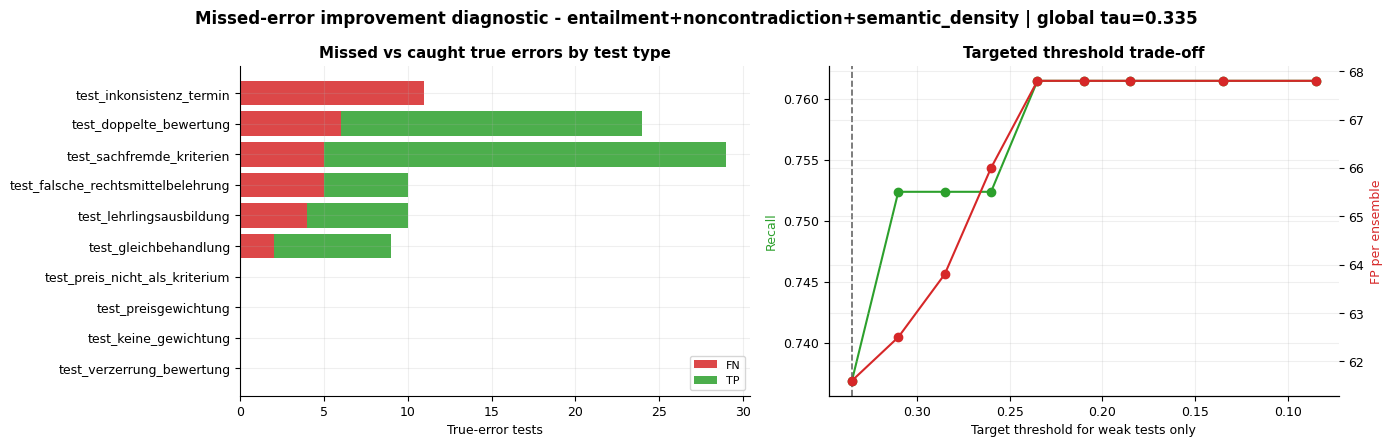

In [16]:
# Follow-up diagnostic: where do the 0% catch misses come from, and would targeted thresholds help?
# Requires the previous bimodality cell: project_test_df, project_upload_df, missed_error_tests, TAU.
# This cell does not change the selected production config; it only quantifies possible fixes.

BASELINE_FLAG_COL = "pred_error"
WEAK_TEST_TOP_N = 4
TARGET_THRESHOLD_STEPS = [0.00, 0.025, 0.05, 0.075, 0.10, 0.125, 0.15, 0.20, 0.25]

analysis_df = project_test_df.copy()
analysis_df[BASELINE_FLAG_COL] = analysis_df[BASELINE_FLAG_COL].astype(bool)
analysis_df["score_margin_to_tau"] = TAU - analysis_df["test_ensemble_error_score"]
analysis_df["is_error"] = analysis_df["error_label"].astype(int).eq(1)
analysis_df["is_tp"] = analysis_df[BASELINE_FLAG_COL] & analysis_df["is_error"]
analysis_df["is_fp"] = analysis_df[BASELINE_FLAG_COL] & ~analysis_df["is_error"]
analysis_df["is_fn"] = ~analysis_df[BASELINE_FLAG_COL] & analysis_df["is_error"]


def _flag_metric_series(df, flag_col):
    pred = df[flag_col].astype(bool).to_numpy()
    y = df["error_label"].astype(int).to_numpy() == 1
    tp = int((pred & y).sum())
    fp = int((pred & ~y).sum())
    fn = int((~pred & y).sum())
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    f2 = 5 * precision * recall / max(4 * precision + recall, 1e-12)
    return pd.Series({
        "flagged": int(pred.sum()),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
    })


def _mean_by_ensemble(df, flag_col):
    per_ensemble = pd.DataFrame([
        _flag_metric_series(group, flag_col)
        for _, group in df.groupby("ensemble", sort=True)
    ])
    return per_ensemble.mean(numeric_only=True)


# 1) Per-test-code performance. This shows whether misses are concentrated in specific tests.
per_test_rows = []
for test_code, g in analysis_df.groupby("test_code", dropna=False):
    metrics = _flag_metric_series(g, BASELINE_FLAG_COL).to_dict()
    missed_scores = g.loc[g["is_fn"], "test_ensemble_error_score"]
    error_scores = g.loc[g["is_error"], "test_ensemble_error_score"]
    per_test_rows.append({
        "test_code": test_code,
        "n_instances": len(g),
        "n_errors": int(g["is_error"].sum()),
        "mean_error_score": float(error_scores.mean()) if len(error_scores) else np.nan,
        "max_missed_score": float(missed_scores.max()) if len(missed_scores) else np.nan,
        "closest_missed_margin": float((TAU - missed_scores).min()) if len(missed_scores) else np.nan,
        "missed_within_0.05": int(((TAU - missed_scores) <= 0.05).sum()) if len(missed_scores) else 0,
        **metrics,
    })

per_test_diagnostics = (
    pd.DataFrame(per_test_rows)
    .sort_values(["fn", "recall", "fp"], ascending=[False, True, True])
    .reset_index(drop=True)
)

print("Per-test-code diagnostic at the selected global threshold:")
display(per_test_diagnostics.round(3))

# 2) Project-level view of fully missed uploads, including whether they are near or far below threshold.
zero_missed_detail = analysis_df[
    analysis_df["is_fn"]
].merge(
    zero_catch_uploads[["ensemble", "project_id"]],
    on=["ensemble", "project_id"],
    how="inner",
)

zero_project_summary = pd.DataFrame()
if not zero_missed_detail.empty:
    zero_project_summary = (
        zero_missed_detail
        .groupby("project_id", as_index=False)
        .agg(
            zero_catch_uploads=("ensemble", "nunique"),
            missed_errors=("test_code", "count"),
            mean_missed_score=("test_ensemble_error_score", "mean"),
            max_missed_score=("test_ensemble_error_score", "max"),
            closest_margin_to_tau=("score_margin_to_tau", "min"),
        )
        .sort_values(["zero_catch_uploads", "missed_errors"], ascending=[False, False])
    )
    common_tests = (
        zero_missed_detail
        .groupby("project_id")["test_code"]
        .agg(lambda s: ", ".join(s.value_counts().head(3).index.astype(str)))
        .rename("common_missed_tests")
        .reset_index()
    )
    zero_project_summary = zero_project_summary.merge(common_tests, on="project_id", how="left")

print("0% catch projects: are the missed true errors near the global threshold or far below it?")
display(zero_project_summary.round(3))

print("Missed true-error rows closest to the threshold:")
display(
    analysis_df[analysis_df["is_fn"]]
    .sort_values("score_margin_to_tau")
    [["ensemble", "project_id", "test_code", "test_ensemble_error_score", "score_margin_to_tau"]]
    .head(25)
    .round(3)
)

# 3) Simulate targeted lower thresholds only for the weak missed test types.
weak_tests = (
    missed_error_tests["test_code"]
    .value_counts()
    .head(WEAK_TEST_TOP_N)
    .index
    .tolist()
)

baseline_mean = _mean_by_ensemble(analysis_df, BASELINE_FLAG_COL)
rows = []
for step in TARGET_THRESHOLD_STEPS:
    target_tau = max(0.0, round(TAU - step, 3))
    tmp = analysis_df.copy()
    weak_mask = tmp["test_code"].isin(weak_tests)
    tmp["targeted_flag"] = tmp[BASELINE_FLAG_COL] | (
        weak_mask & (tmp["test_ensemble_error_score"] >= target_tau)
    )
    m = _mean_by_ensemble(tmp, "targeted_flag")
    rows.append({
        "weak_tests": "+".join(weak_tests),
        "global_tau": TAU,
        "target_tau_for_weak_tests": target_tau,
        "added_flags_per_ensemble": m["flagged"] - baseline_mean["flagged"],
        "added_tp_per_ensemble": m["tp"] - baseline_mean["tp"],
        "added_fp_per_ensemble": m["fp"] - baseline_mean["fp"],
        **m.to_dict(),
    })

targeted_threshold_sweep = pd.DataFrame(rows)
print(f"Targeted threshold sweep for weak tests: {weak_tests}")
display(targeted_threshold_sweep.round(3))

# 4) Single-test sweeps, so we can see which weak test is worth a special rule.
single_rows = []
for test_code in weak_tests:
    for step in TARGET_THRESHOLD_STEPS:
        target_tau = max(0.0, round(TAU - step, 3))
        tmp = analysis_df.copy()
        weak_mask = tmp["test_code"].eq(test_code)
        tmp["targeted_flag"] = tmp[BASELINE_FLAG_COL] | (
            weak_mask & (tmp["test_ensemble_error_score"] >= target_tau)
        )
        m = _mean_by_ensemble(tmp, "targeted_flag")
        single_rows.append({
            "test_code": test_code,
            "target_tau": target_tau,
            "added_flags_per_ensemble": m["flagged"] - baseline_mean["flagged"],
            "added_tp_per_ensemble": m["tp"] - baseline_mean["tp"],
            "added_fp_per_ensemble": m["fp"] - baseline_mean["fp"],
            "precision": m["precision"],
            "recall": m["recall"],
            "f2": m["f2"],
        })

single_test_threshold_sweep = pd.DataFrame(single_rows)
print("Single-test targeted threshold sweeps:")
display(
    single_test_threshold_sweep
    .sort_values(["test_code", "target_tau"], ascending=[True, False])
    .round(3)
)

# ---- Compact plots --------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax1, ax2 = axes

plot_diag = per_test_diagnostics.head(10).sort_values("fn", ascending=True)
ax1.barh(np.arange(len(plot_diag)), plot_diag["fn"], color="#D62728", alpha=0.85, label="FN")
ax1.barh(np.arange(len(plot_diag)), plot_diag["tp"], left=plot_diag["fn"], color="#2CA02C", alpha=0.85, label="TP")
ax1.set_yticks(np.arange(len(plot_diag)))
ax1.set_yticklabels(plot_diag["test_code"])
ax1.set_xlabel("True-error tests")
ax1.set_title("Missed vs caught true errors by test type", fontweight="semibold")
ax1.legend(fontsize=8, loc="lower right")

if not targeted_threshold_sweep.empty:
    ax2.plot(
        targeted_threshold_sweep["target_tau_for_weak_tests"],
        targeted_threshold_sweep["recall"],
        marker="o",
        color="#2CA02C",
        label="recall",
    )
    ax2_twin = ax2.twinx()
    ax2_twin.plot(
        targeted_threshold_sweep["target_tau_for_weak_tests"],
        targeted_threshold_sweep["fp"],
        marker="o",
        color="#D62728",
        label="FP / ensemble",
    )
    ax2.axvline(TAU, color="#666666", linestyle="--", linewidth=1.2, label="global tau")
    ax2.set_xlabel("Target threshold for weak tests only")
    ax2.set_ylabel("Recall", color="#2CA02C")
    ax2_twin.set_ylabel("FP per ensemble", color="#D62728")
    ax2.set_title("Targeted threshold trade-off", fontweight="semibold")
    ax2.invert_xaxis()

fig.suptitle(
    f"Missed-error improvement diagnostic - {'+'.join(METHODS)} | global tau={TAU:.3f}",
    fontsize=12,
    fontweight="semibold",
)
plt.tight_layout()
plt.show()


The catch-rate analysis shows that errors are not missed evenly. Most uploads with errors are fully caught, but a minority are missed entirely. These complete misses are concentrated in `test_inkonsistenz_termin` and `test_falsche_rechtsmittelbelehrung`.


### GPT120B second-stage judge

This cell applies the selected first-stage UE operating point to the new five combined ensembles, then sends only the flagged answer sets to GPT120B. The judge sees answers 1..5, not the original prompt. A UE flag is kept only when the judge returns `suspicious=true`; unparsed/error calls keep the UE flag to protect recall.


In [ ]:
# Second-stage consistency judge for flags on the new 5 combined ensembles.
# Uses the 10-ensemble grid-search operating point with recall >= 0.70,
# scale=[0.05, 0.95], with gate derived as tau - 0.10:
#   methods=entailment+noncontradiction+semantic_density, tau=0.335.
# The judge sees only answers 1..5, not the original prompt. A UE flag is kept only when the judge
# says the answer set is suspicious/inconsistent; failed or unparsed judge calls keep the UE flag.

from pathlib import Path
import hashlib
import json
import os
import re
import sys
import time
from typing import Optional

import numpy as np
import pandas as pd
import requests
from dotenv import load_dotenv
from IPython.display import display

_g = globals()
if str(DATA_DIR) not in sys.path:
    sys.path.insert(0, str(DATA_DIR))
load_dotenv(DATA_DIR / ".env", override=False)

from calibration_helpers import (
    CHECK_KEY,
    THRESHOLDS,
    add_model_error_target,
    build_test_work,
    learn_global_orientation_and_bounds,
    make_gated_soft_or,
    per_threshold_summary,
    require_constant_within_tests,
    threshold_metrics,
)

TARGET_BASE_MODEL = "GPT20B"
ENSEMBLE_IDS = [1, 2, 3, 4, 5]
COMBINED_ENSEMBLE_FILES = {
    1: "GPT20_Ensemble_all_v1.csv",
    2: "GPT20_Ensemble_all_v2.csv",
    3: "GPT20_Ensemble_all_v3.csv",
    4: "GPT20_Ensemble_all_v4.csv",
    5: "GPT20_Ensemble_all_v5.csv",
}

UE_METHODS = ["entailment", "noncontradiction", "semantic_density"]
UE_Q_LOW = 0.05
UE_Q_HIGH = 0.95
UE_THRESHOLD = 0.335
MIN_THRESHOLD_GATE_GAP = _g.get("MIN_THRESHOLD_GATE_GAP", 0.10)
UE_GATE_FLOOR = round(UE_THRESHOLD - MIN_THRESHOLD_GATE_GAP, 3)
UE_AGG_NAME = f"gated_soft_or_floor_{UE_GATE_FLOOR:.3f}"
UE_AGG_FN = make_gated_soft_or(UE_GATE_FLOOR)

ANSWER_COLS = [
    "answer_1_original",
    "answer_2_sample",
    "answer_3_sample",
    "answer_4_sample",
    "answer_5_sample",
]
OPTIONAL_ID_COLS = ["base_model", "test_name", "gt", "pred", "check_pred", "check_result_line"]

JUDGE_MODEL = "openai/gpt-oss-120b"
JUDGE_URL = "https://openrouter.ai/api/v1/chat/completions"
JUDGE_TEMPERATURE = 0.0
JUDGE_MAX_TOKENS = 500
JUDGE_MAX_RETRIES = 5
JUDGE_BACKOFF_BASE = 2.0
JUDGE_PROMPT_VERSION = "answer_consistency_v3_critical_no_prompt_de"
# Empty trial name writes the selected/final run to unsuffixed files:
# gpt120b_flag_review_metrics.csv, test_flags.csv, check_rows.csv.
JUDGE_TRIAL_NAME = ""
JUDGE_OUTPUT_PREFIX = "gpt120b_flag_review"
MAX_JUDGE_CALLS = None

def judge_output_path(kind: str) -> Path:
    suffix = f"_{JUDGE_TRIAL_NAME}" if JUDGE_TRIAL_NAME else ""
    return DATA_DIR / f"{JUDGE_OUTPUT_PREFIX}_{kind}{suffix}.csv"


CHECK_REVIEW_PATH = judge_output_path("check_rows")
TEST_REVIEW_PATH = judge_output_path("test_flags")
METRICS_REVIEW_PATH = judge_output_path("metrics")
JUDGE_CACHE_PATH = DATA_DIR / f"{JUDGE_OUTPUT_PREFIX}_cache.jsonl"


def load_combined_ensemble_full(data_dir, ensemble_id, methods, target_base_model=None):
    path = Path(data_dir) / COMBINED_ENSEMBLE_FILES[ensemble_id]
    header = pd.read_csv(path, nrows=0).columns.tolist()
    wanted = [*OPTIONAL_ID_COLS, *CHECK_KEY, "match", *methods, *ANSWER_COLS]
    usecols = [c for c in wanted if c in header]
    df = pd.read_csv(path, usecols=usecols)

    if target_base_model is not None and "base_model" in df.columns:
        df = df[df["base_model"] == target_base_model].copy()

    required = [*CHECK_KEY, "match", *methods, *ANSWER_COLS]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name}: missing required columns: {missing}")

    df = add_model_error_target(df, "match")
    require_constant_within_tests(df, "label", f"combined ensemble {ensemble_id}")
    df["ensemble"] = ensemble_id
    return df


def fit_ue_params(ensemble_dfs):
    pooled = pd.concat(ensemble_dfs, ignore_index=True)
    return pd.DataFrame([
        learn_global_orientation_and_bounds(
            pooled,
            method,
            q_low=UE_Q_LOW,
            q_high=UE_Q_HIGH,
            agg_fn=UE_AGG_FN,
            scale=True,
        )
        for method in UE_METHODS
    ])


def build_ue_test_flags(ensemble_dfs, params):
    rows = []
    threshold_rows = []
    for df in ensemble_dfs:
        ensemble_id = int(df["ensemble"].iloc[0])
        tw = build_test_work(df, params, UE_METHODS, agg_fn=UE_AGG_FN, scale=True)
        tw["ensemble"] = ensemble_id
        tw["ue_threshold"] = UE_THRESHOLD
        tw["ue_flag"] = tw["test_ensemble_error_score"] >= UE_THRESHOLD
        rows.append(tw)

        y = tw["error_label"].astype(int).to_numpy()
        s = tw["test_ensemble_error_score"].to_numpy(dtype=float)
        for tau in THRESHOLDS:
            m = threshold_metrics(y, s, tau)
            m["ensemble"] = ensemble_id
            threshold_rows.append(m)

    tests = pd.concat(rows, ignore_index=True)
    summary = per_threshold_summary(pd.DataFrame(threshold_rows))
    chosen = summary.loc[np.isclose(summary["threshold"], UE_THRESHOLD)].iloc[0]
    return tests, summary, chosen


def answer_payload(row):
    parts = []
    for i, col in enumerate(ANSWER_COLS, start=1):
        value = row.get(col, "")
        text = "" if pd.isna(value) else str(value).strip()
        parts.append(f"ANSWER {i}:\n{text if text else '[missing]'}")
    return "\n\n".join(parts)


def judge_cache_key(row):
    key_obj = {
        "prompt_version": JUDGE_PROMPT_VERSION,
        "judge_model": JUDGE_MODEL,
        "ensemble": int(row["ensemble"]),
        "project_id": str(row["project_id"]),
        "test_code": str(row["test_code"]),
        "check_code": str(row["check_code"]),
        "answers": ["" if pd.isna(row.get(c, "")) else str(row.get(c, "")) for c in ANSWER_COLS],
    }
    raw = json.dumps(key_obj, ensure_ascii=False, sort_keys=True)
    return hashlib.sha256(raw.encode("utf-8")).hexdigest()


def load_judge_cache(path):
    cache = {}
    if not path.exists():
        return cache
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                item = json.loads(line)
            except json.JSONDecodeError:
                continue
            key = item.get("cache_key")
            if key:
                cache[key] = item
    return cache


def append_judge_cache(path, item):
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")


def parse_suspicious(raw_text: str) -> Optional[bool]:
    text = (raw_text or "").strip()
    try:
        parsed = json.loads(text)
        if isinstance(parsed, dict):
            value = parsed.get("suspicious")
            if isinstance(value, bool):
                return value
            if isinstance(value, str) and value.strip().lower() in {"true", "false", "yes", "no", "ja", "nein"}:
                return value.strip().lower() in {"true", "yes", "ja"}
    except json.JSONDecodeError:
        pass

    m = re.search(r'"?suspicious"?\s*:\s*(true|false|yes|no|ja|nein)', text, re.IGNORECASE)
    if m:
        return m.group(1).lower() in {"true", "yes", "ja"}
    first = text.splitlines()[0].strip().lower() if text.splitlines() else ""
    if first.startswith(("yes", "ja", "true")):
        return True
    if first.startswith(("no", "nein", "false")):
        return False
    return None


def call_consistency_judge(row):
    api_key = os.getenv("OPENROUTER_API_KEY")
    if not api_key:
        raise RuntimeError("OPENROUTER_API_KEY is not set. Add it to uncertainty_estimation/.env or the environment.")

    system = (
        "Du bist ein sehr strenger Konsistenzprüfer. Du erhältst fünf Antworten auf dieselbe unbekannte Aufgabe. "
        "Der ursprüngliche Prompt wird absichtlich nicht bereitgestellt. Deine Aufgabe ist es, ausschließlich "
        "die Antworten miteinander zu vergleichen.\n\n"
        "Bewerte die Antworten nach folgenden Kriterien:\n"
        "- Widersprechen sich Aussagen direkt oder indirekt?\n"
        "- Treffen die Antworten unterschiedliche Schlussfolgerungen oder Ergebnisse?\n"
        "- Enthält eine Antwort Behauptungen, die von den anderen Antworten nicht bestätigt oder gestützt werden?\n"
        "- Gibt es auch kleine inhaltliche Abweichungen zwischen den Antworten?\n"
        "- Begründen die Antworten dasselbe Ergebnis mit unterschiedlichen entscheidenden Tatsachen, Kriterien, "
        "Zahlen, Bedingungen oder Annahmen?\n\n"
        "WICHTIG:\n"
        "- Bereits kleine inhaltliche Unterschiede gelten als verdächtig.\n"
        "- Wenn Aussagen nicht übereinstimmen oder sich nicht gegenseitig stützen, ist das verdächtig.\n"
        "- Auch zusätzliche oder fehlende relevante Informationen im Vergleich zu den anderen Antworten sind verdächtig.\n"
        "- Eine gleiche finale Antwort, z.B. dasselbe ERGEBNIS, reicht NICHT aus, um suspicious = false zu setzen.\n"
        "- Wenn die Antworten dasselbe Ergebnis nennen, aber unterschiedliche oder nicht gegenseitig gestützte "
        "Begründungen liefern, ist das verdächtig.\n\n"
        "Ignoriere nur:\n"
        "- Rein sprachliche Paraphrasen mit identischer Bedeutung\n"
        "- Unterschiede im Stil oder in der Formulierung\n\n"
        "Antworte ausschließlich im JSON-Format."
    )

    user = (
        "Vergleiche die folgenden fünf Antworten sorgfältig.\n\n"
        "Sind sie in irgendeiner Weise inhaltlich unterschiedlich, widersprüchlich oder nicht gegenseitig gestützt?\n\n"
        "Gib exakt dieses JSON zurück:\n"
        '{"suspicious": true/false, "reason": "kurze, präzise Begründung"}\n\n'
        + answer_payload(row)
    )

    payload = {
        "model": JUDGE_MODEL,
        "messages": [
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
        "temperature": JUDGE_TEMPERATURE,
        "max_tokens": JUDGE_MAX_TOKENS,
    }
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "HTTP-Referer": "https://localhost/uncertainty-estimation",
        "X-Title": "GPT20B UE consistency review",
    }

    last_error = None
    for attempt in range(1, JUDGE_MAX_RETRIES + 1):
        try:
            resp = requests.post(JUDGE_URL, json=payload, headers=headers, timeout=180)
            resp.raise_for_status()
            data = resp.json()
            raw = (data.get("choices") or [{}])[0].get("message", {}).get("content", "")
            suspicious = parse_suspicious(raw)
            return suspicious, raw, "ok" if suspicious is not None else "unparsed"
        except Exception as exc:
            last_error = repr(exc)
            if attempt < JUDGE_MAX_RETRIES:
                time.sleep(min(90.0, JUDGE_BACKOFF_BASE ** attempt))
    return None, last_error, "error"


print("Starting second-stage judge workflow...", flush=True)
print(f"Data files: GPT20_Ensemble_all_v1..v5 for {TARGET_BASE_MODEL}", flush=True)
print(
    f"UE config: methods={'+'.join(UE_METHODS)}, agg={UE_AGG_NAME}, "
    f"scale=[{UE_Q_LOW}, {UE_Q_HIGH}], threshold={UE_THRESHOLD}",
    flush=True,
)
print(f"Judge model: {JUDGE_MODEL}; MAX_JUDGE_CALLS={MAX_JUDGE_CALLS}", flush=True)

ensemble_dfs = [
    load_combined_ensemble_full(DATA_DIR, eid, UE_METHODS, target_base_model=TARGET_BASE_MODEL)
    for eid in ENSEMBLE_IDS
]
print(
    f"Loaded {len(ensemble_dfs)} ensembles, "
    f"{sum(len(df) for df in ensemble_dfs)} check rows total.",
    flush=True,
)

print("Fitting q05/q95 orientation/scaling on the new 5 ensembles...", flush=True)
ue_params = fit_ue_params(ensemble_dfs)
print("Building test-level UE flags...", flush=True)
ue_tests, threshold_summary, threshold_row = build_ue_test_flags(ensemble_dfs, ue_params)
flagged_tests = ue_tests[ue_tests["ue_flag"]].copy()

print("UE operating point on new 5 ensembles:", flush=True)
display(pd.DataFrame([threshold_row]).round(3))
flagged_per_ensemble = flagged_tests.groupby("ensemble").size()
flagged_mean = float(flagged_per_ensemble.mean()) if len(flagged_per_ensemble) else 0.0
print(
    f"Flagged tests before judge review: {len(flagged_tests)} total, "
    f"{flagged_mean:.1f} per ensemble",
    flush=True,
)

key_cols = ["ensemble", "project_id", "test_code"]
all_checks = pd.concat(ensemble_dfs, ignore_index=True)
flagged_checks = all_checks.merge(flagged_tests[key_cols], on=key_cols, how="inner").copy()
flagged_checks["cache_key"] = flagged_checks.apply(judge_cache_key, axis=1)

cache = load_judge_cache(JUDGE_CACHE_PATH)
cache_hits = int(flagged_checks["cache_key"].isin(cache).sum()) if not flagged_checks.empty else 0
cache_misses = int(len(flagged_checks) - cache_hits)
calls_planned = cache_misses if MAX_JUDGE_CALLS is None else min(cache_misses, MAX_JUDGE_CALLS)
print(
    f"Flagged check rows to review: {len(flagged_checks)}; "
    f"cache hits={cache_hits}; new judge calls planned={calls_planned}",
    flush=True,
)

review_rows = []
calls_made = 0
limit_notice_printed = False
for idx, row in flagged_checks.reset_index(drop=True).iterrows():
    cache_key = row["cache_key"]
    cached = cache.get(cache_key)
    if cached is None:
        if MAX_JUDGE_CALLS is not None and calls_made >= MAX_JUDGE_CALLS:
            if not limit_notice_printed:
                print("MAX_JUDGE_CALLS reached; remaining uncached rows are marked not_run_limit.", flush=True)
                limit_notice_printed = True
            cached = {
                "cache_key": cache_key,
                "judge_model": JUDGE_MODEL,
                "judge_status": "not_run_limit",
                "judge_suspicious": None,
                "judge_raw": "MAX_JUDGE_CALLS reached",
            }
        else:
            print(
                f"[{calls_made + 1}/{calls_planned}] Calling judge for "
                f"ensemble={row['ensemble']}, project={row['project_id']}, "
                f"test={str(row['test_code'])[:80]}, check={str(row['check_code'])[:80]}",
                flush=True,
            )
            suspicious, raw, status = call_consistency_judge(row)
            cached = {
                "cache_key": cache_key,
                "judge_model": JUDGE_MODEL,
                "judge_status": status,
                "judge_suspicious": suspicious,
                "judge_raw": raw,
            }
            append_judge_cache(JUDGE_CACHE_PATH, cached)
            cache[cache_key] = cached
            calls_made += 1
            print(
                f"[{calls_made}/{calls_planned}] judge result: "
                f"status={status}, suspicious={suspicious}",
                flush=True,
            )

    review_rows.append({
        "ensemble": int(row["ensemble"]),
        "project_id": row["project_id"],
        "test_code": row["test_code"],
        "check_code": row["check_code"],
        "label": int(row["label"]),
        "error_label": int(row["error_label"]),
        "cache_key": cache_key,
        "judge_model": cached.get("judge_model", JUDGE_MODEL),
        "judge_status": cached.get("judge_status"),
        "judge_suspicious": cached.get("judge_suspicious"),
        "judge_raw": cached.get("judge_raw"),
    })

check_review = pd.DataFrame(review_rows)
if not check_review.empty:
    check_review.to_csv(CHECK_REVIEW_PATH, index=False)

if check_review.empty:
    judge_by_test = pd.DataFrame(columns=key_cols + ["judge_any_suspicious", "judge_all_complete", "n_judged_checks"])
else:
    tmp = check_review.copy()
    tmp["judge_suspicious_bool"] = tmp["judge_suspicious"].map(lambda x: bool(x) if isinstance(x, bool) else False)
    tmp["judge_complete_bool"] = tmp["judge_status"].eq("ok") & tmp["judge_suspicious"].map(lambda x: isinstance(x, bool))
    judge_by_test = (
        tmp.groupby(key_cols, as_index=False)
        .agg(
            judge_any_suspicious=("judge_suspicious_bool", "max"),
            judge_all_complete=("judge_complete_bool", "min"),
            n_judged_checks=("check_code", "count"),
            n_suspicious_checks=("judge_suspicious_bool", "sum"),
        )
    )

final_tests = ue_tests.merge(judge_by_test, on=key_cols, how="left")
final_tests["judge_any_suspicious"] = final_tests["judge_any_suspicious"].fillna(False).astype(bool)
final_tests["judge_all_complete"] = final_tests["judge_all_complete"].fillna(False).astype(bool)
final_tests["n_judged_checks"] = final_tests["n_judged_checks"].fillna(0).astype(int)
final_tests["n_suspicious_checks"] = final_tests["n_suspicious_checks"].fillna(0).astype(int)

final_tests["post_judge_flag"] = final_tests["ue_flag"] & (
    final_tests["judge_any_suspicious"] | ~final_tests["judge_all_complete"]
)
final_tests["removed_by_judge"] = final_tests["ue_flag"] & ~final_tests["post_judge_flag"]
final_tests.to_csv(TEST_REVIEW_PATH, index=False)


def flag_metrics(df, flag_col):
    pred = df[flag_col].astype(bool).to_numpy()
    y = df["error_label"].astype(int).to_numpy() == 1
    tp = int((pred & y).sum())
    fp = int((pred & ~y).sum())
    fn = int((~pred & y).sum())
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    f2 = 5 * precision * recall / max(4 * precision + recall, 1e-12)
    return pd.Series({
        "flagged": int(pred.sum()),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
    })


metrics = []
for name, flag_col in [("before_judge", "ue_flag"), ("after_judge", "post_judge_flag")]:
    per_ensemble = pd.DataFrame([
        flag_metrics(group, flag_col)
        for _, group in final_tests.groupby("ensemble", sort=True)
    ])
    row = per_ensemble.mean(numeric_only=True).to_dict()
    row["stage"] = name
    metrics.append(row)

metrics_df = pd.DataFrame(metrics)[["stage", "flagged", "tp", "fp", "fn", "precision", "recall", "f1", "f2"]]
metrics_df.insert(0, "trial", JUDGE_TRIAL_NAME or "selected")
metrics_df.to_csv(METRICS_REVIEW_PATH, index=False)

print(f"Judge calls made in this run: {calls_made}")
print(f"Check-level review written to: {CHECK_REVIEW_PATH}")
print(f"Test-level final flags written to: {TEST_REVIEW_PATH}")
print(f"Metrics written to: {METRICS_REVIEW_PATH}")
display(metrics_df.round(3))
display(final_tests[final_tests["ue_flag"]].sort_values(["ensemble", "project_id", "test_code"]).head(20))



In [23]:
# Display saved GPT120B judge-prompt comparisons only.
# This cell does not call the judge API. It only reads the saved metrics CSVs.

from pathlib import Path
import re
import pandas as pd
from IPython.display import display

JUDGE_OUTPUT_PREFIX = "gpt120b_flag_review"
METRICS_FILES = [
    DATA_DIR / f"{JUDGE_OUTPUT_PREFIX}_metrics_v1.csv",
    DATA_DIR / f"{JUDGE_OUTPUT_PREFIX}_metrics_v2.csv",
    DATA_DIR / f"{JUDGE_OUTPUT_PREFIX}_metrics_v3.csv",
    DATA_DIR / f"{JUDGE_OUTPUT_PREFIX}_metrics.csv",
]

TRIAL_LABELS = {
    "v1": "prompt v1",
    "v2": "prompt v2",
    "v3": "prompt v3",
    "selected": "selected prompt",
}


def trial_from_metrics_path(path: Path) -> str:
    match = re.match(rf"{JUDGE_OUTPUT_PREFIX}_metrics(?:_(.+))?$", path.stem)
    if not match:
        return path.stem
    return match.group(1) or "selected"


parts = []
missing = []
for path in METRICS_FILES:
    if not path.exists():
        missing.append(path.name)
        continue
    part = pd.read_csv(path)
    trial = trial_from_metrics_path(path)
    if "trial" not in part.columns:
        part.insert(0, "trial", trial)
    else:
        part["trial"] = part["trial"].fillna(trial).replace({"": trial})
    part["trial"] = trial
    part["trial_label"] = part["trial"].map(TRIAL_LABELS).fillna(part["trial"])
    part["metrics_file"] = path.name
    parts.append(part)

if not parts:
    raise FileNotFoundError(
        "No saved GPT120B judge metrics files found. Expected one or more of: "
        + ", ".join(path.name for path in METRICS_FILES)
    )

judge_comparison = pd.concat(parts, ignore_index=True)
stage_order = {"before_judge": 0, "before_gpt120b": 0, "after_judge": 1, "after_gpt120b": 1}
trial_order = {"v1": 1, "v2": 2, "v3": 3, "selected": 4}
judge_comparison["_trial_order"] = judge_comparison["trial"].map(trial_order).fillna(99)
judge_comparison["_stage_order"] = judge_comparison["stage"].map(stage_order).fillna(99)
judge_comparison = (
    judge_comparison
    .sort_values(["_trial_order", "_stage_order", "stage"])
    .drop(columns=["_trial_order", "_stage_order"])
    .reset_index(drop=True)
)

print("Saved GPT120B judge-prompt comparison:")
if missing:
    print("Missing optional metrics files:", missing)

display_cols = [
    "trial_label", "stage", "flagged", "tp", "fp", "fn",
    "precision", "recall", "f1", "f2", "metrics_file",
]
display(judge_comparison[[c for c in display_cols if c in judge_comparison.columns]].round(3))

after_judge = judge_comparison[judge_comparison["stage"].isin(["after_judge", "after_gpt120b"])].copy()
if not after_judge.empty:
    print("After-judge rows sorted by F2, then precision:")
    display(
        after_judge
        .sort_values(["f2", "precision", "recall"], ascending=[False, False, False])
        [[c for c in display_cols if c in after_judge.columns]]
        .round(3)
    )


Saved GPT120B judge-prompt comparison:
Missing optional metrics files: ['gpt120b_flag_review_metrics.csv']


,trial_label,stage,flagged,tp,fp,fn,precision,recall,f1,f2,metrics_file
0,prompt v1,before_gpt120b,73.8,10.0,63.8,3.4,0.135,0.744,0.228,0.390,gpt120b_flag_review_metrics_v1.csv
1,prompt v1,after_gpt120b,24.0,6.8,17.2,6.6,0.283,0.508,0.362,0.437,gpt120b_flag_review_metrics_v1.csv
2,prompt v2,before_gpt120b,73.8,10.0,63.8,3.4,0.135,0.744,0.228,0.390,gpt120b_flag_review_metrics_v2.csv
3,prompt v2,after_gpt120b,19.0,6.6,12.4,6.8,0.350,0.490,0.406,0.452,gpt120b_flag_review_metrics_v2.csv
4,prompt v3,before_judge,73.8,10.0,63.8,3.4,0.135,0.744,0.228,0.390,gpt120b_flag_review_metrics_v3.csv
5,prompt v3,after_judge,32.0,7.8,24.2,5.6,0.245,0.581,0.343,0.453,gpt120b_flag_review_metrics_v3.csv


After-judge rows sorted by F2, then precision:


,trial_label,stage,flagged,tp,fp,fn,precision,recall,f1,f2,metrics_file
5,prompt v3,after_judge,32.0,7.8,24.2,5.6,0.245,0.581,0.343,0.453,gpt120b_flag_review_metrics_v3.csv
3,prompt v2,after_gpt120b,19.0,6.6,12.4,6.8,0.350,0.490,0.406,0.452,gpt120b_flag_review_metrics_v2.csv
1,prompt v1,after_gpt120b,24.0,6.8,17.2,6.6,0.283,0.508,0.362,0.437,gpt120b_flag_review_metrics_v1.csv


### Same-recall comparison: GPT120B vs threshold only

This cell compares the GPT120B v4 post-judge recall against threshold-only baselines on the same new five ensembles. It answers whether simply raising the threshold would produce the same false-positive reduction.


In [24]:
# Compare GPT120B judge against threshold-only baselines.
# Goal: does GPT120B reduce false positives after the UE flagger, without losing more recall
# than an ordinary threshold-only operating point would at roughly the same recall?

from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display


if str(DATA_DIR) not in sys.path:
    sys.path.insert(0, str(DATA_DIR))

from calibration_helpers import (
    CHECK_KEY,
    THRESHOLDS,
    add_model_error_target,
    build_test_work,
    learn_global_orientation_and_bounds,
    make_gated_soft_or,
    per_threshold_summary,
    require_constant_within_tests,
    soft_or,
    threshold_metrics,
)

TARGET_BASE_MODEL = _g.get("TARGET_BASE_MODEL", "GPT20B")
UE_METHODS = _g.get("UE_METHODS", ["entailment", "noncontradiction", "semantic_density"])
UE_THRESHOLD = float(_g.get("UE_THRESHOLD", 0.335))
UE_GATE_FLOOR = float(_g.get("UE_GATE_FLOOR", 0.235))
UE_Q_LOW = float(_g.get("UE_Q_LOW", 0.05))
UE_Q_HIGH = float(_g.get("UE_Q_HIGH", 0.95))
SCALE = bool(_g.get("SCALE", True))

ENSEMBLE_IDS = [1, 2, 3, 4, 5]
COMBINED_ENSEMBLE_FILES = {
    1: "GPT20_Ensemble_all_v1.csv",
    2: "GPT20_Ensemble_all_v2.csv",
    3: "GPT20_Ensemble_all_v3.csv",
    4: "GPT20_Ensemble_all_v4.csv",
    5: "GPT20_Ensemble_all_v5.csv",
}

METRICS_CANDIDATES = [
    DATA_DIR / "gpt120b_flag_review_metrics_v3.csv",
    DATA_DIR / "gpt120b_flag_review_metrics.csv",
]
METRICS_PATH = next((path for path in METRICS_CANDIDATES if path.exists()), None)
if METRICS_PATH is None:
    raise FileNotFoundError(
        "Could not find selected GPT120B judge metrics. Tried: "
        + ", ".join(str(path) for path in METRICS_CANDIDATES)
    )
print(f"Using judge metrics: {METRICS_PATH}")
judge_metrics = pd.read_csv(METRICS_PATH)

after_rows = judge_metrics[judge_metrics["stage"].isin(["after_gpt120b", "after_judge"])]
before_rows = judge_metrics[judge_metrics["stage"].isin(["before_gpt120b", "before_judge"])]
if after_rows.empty:
    raise ValueError(f"No after-judge row found in {METRICS_PATH}; stages={judge_metrics['stage'].tolist()}")
if before_rows.empty:
    raise ValueError(f"No before-judge row found in {METRICS_PATH}; stages={judge_metrics['stage'].tolist()}")

judge_after = after_rows.iloc[0]
judge_before = before_rows.iloc[0]
TARGET_RECALL = float(judge_after["recall"])


def load_combined_ensemble_for_compare(data_dir, ensemble_id, methods, target_base_model=None):
    path = Path(data_dir) / COMBINED_ENSEMBLE_FILES[ensemble_id]
    needed_cols = [*CHECK_KEY, "match", *methods]
    if target_base_model is not None:
        needed_cols.append("base_model")
    df = pd.read_csv(path, usecols=needed_cols)
    if target_base_model is not None and "base_model" in df.columns:
        df = df[df["base_model"] == target_base_model].copy()
    df = add_model_error_target(df, "match")
    require_constant_within_tests(df, "label", f"combined ensemble {ensemble_id}")
    df["ensemble"] = ensemble_id
    return df


def fit_params_for_compare(train_dfs, methods, agg_fn):
    pooled = pd.concat(train_dfs, ignore_index=True)
    return pd.DataFrame([
        learn_global_orientation_and_bounds(
            pooled,
            method,
            q_low=UE_Q_LOW,
            q_high=UE_Q_HIGH,
            agg_fn=agg_fn,
            scale=SCALE,
        )
        for method in methods
    ])


def threshold_curve(eval_dfs, fit_dfs, methods, agg_fn):
    params = fit_params_for_compare(fit_dfs, methods, agg_fn)
    rows = []
    for df in eval_dfs:
        tw = build_test_work(df, params, methods, agg_fn=agg_fn, scale=SCALE)
        y = tw["error_label"].astype(int).to_numpy()
        s = tw["test_ensemble_error_score"].to_numpy(dtype=float)
        for tau in THRESHOLDS:
            row = threshold_metrics(y, s, float(tau))
            row["threshold"] = float(tau)
            row["ensemble"] = df["ensemble"].iloc[0]
            rows.append(row)
    return per_threshold_summary(pd.DataFrame(rows))


def best_f2_with_recall_at_least(summary, recall_floor):
    viable = summary[summary["recall_error_mean"] >= recall_floor].copy()
    if viable.empty:
        return None
    return viable.sort_values(
        ["f2_error_mean", "fp_error_mean", "n_flagged_mean"],
        ascending=[False, True, True],
    ).iloc[0]


def closest_recall(summary, target_recall):
    tmp = summary.copy()
    tmp["recall_gap"] = (tmp["recall_error_mean"] - target_recall).abs()
    return tmp.sort_values(["recall_gap", "fp_error_mean", "n_flagged_mean"]).iloc[0]


def summarize_curve_row(label, row, selection):
    return {
        "scenario": label,
        "selection": selection,
        "threshold": np.nan if row is None else float(row.get("threshold", np.nan)),
        "flagged": np.nan if row is None else float(row["n_flagged_mean"]),
        "tp": np.nan if row is None else float(row["tp_error_mean"]),
        "fp": np.nan if row is None else float(row["fp_error_mean"]),
        "fn": np.nan if row is None else float(row["fn_error_mean"]),
        "precision": np.nan if row is None else float(row["precision_error_mean"]),
        "recall": np.nan if row is None else float(row["recall_error_mean"]),
        "f1": np.nan if row is None else float(row["f1_error_mean"]),
        "f2": np.nan if row is None else float(row["f2_error_mean"]),
    }


def summarize_judge_row(label, row, selection):
    return {
        "scenario": label,
        "selection": selection,
        "threshold": UE_THRESHOLD,
        "flagged": float(row["flagged"]),
        "tp": float(row["tp"]),
        "fp": float(row["fp"]),
        "fn": float(row["fn"]),
        "precision": float(row["precision"]),
        "recall": float(row["recall"]),
        "f1": float(row["f1"]),
        "f2": float(row["f2"]),
    }


def add_delta_columns(df, baseline_row):
    out = df.copy()
    out["recall_gap_vs_gpt120b"] = out["recall"] - float(baseline_row["recall"])
    out["extra_fp_vs_gpt120b"] = out["fp"] - float(baseline_row["fp"])
    out["extra_flags_vs_gpt120b"] = out["flagged"] - float(baseline_row["flagged"])
    out["tp_delta_vs_gpt120b"] = out["tp"] - float(baseline_row["tp"])
    return out


new5_dfs = [
    load_combined_ensemble_for_compare(DATA_DIR, eid, UE_METHODS, target_base_model=TARGET_BASE_MODEL)
    for eid in ENSEMBLE_IDS
]

# Same scorer combo, no GPT120B judge. Compare plain soft-OR and gated soft-OR threshold-only curves.
soft_curve = threshold_curve(new5_dfs, new5_dfs, UE_METHODS, soft_or)
gated_curve = threshold_curve(new5_dfs, new5_dfs, UE_METHODS, make_gated_soft_or(UE_GATE_FLOOR))

# Table 1: direct effect of the judge at the same first-stage threshold.
judge_effect = pd.DataFrame([
    summarize_judge_row("before_gpt120b", judge_before, "first-stage UE flags before judge"),
    summarize_judge_row("after_gpt120b", judge_after, "UE flags kept only if GPT120B says suspicious"),
])
judge_effect["delta_flagged_vs_before"] = judge_effect["flagged"] - float(judge_before["flagged"])
judge_effect["delta_tp_vs_before"] = judge_effect["tp"] - float(judge_before["tp"])
judge_effect["delta_fp_vs_before"] = judge_effect["fp"] - float(judge_before["fp"])
judge_effect["delta_recall_vs_before"] = judge_effect["recall"] - float(judge_before["recall"])

print("1) Direct GPT120B filtering effect at the same first-stage UE threshold:")
display(judge_effect.round(3))

# Table 2: fair same-recall comparison. This answers the main question.
matched_rows = [
    summarize_judge_row(
        "with_gpt120b_v4_after_judge",
        judge_after,
        "actual second-stage judge result",
    ),
    summarize_curve_row(
        "no_judge_soft_or_closest_to_judge_recall",
        closest_recall(soft_curve, TARGET_RECALL),
        "threshold-only, closest recall to GPT120B",
    ),
    summarize_curve_row(
        "no_judge_gated_closest_to_judge_recall",
        closest_recall(gated_curve, TARGET_RECALL),
        "threshold-only gated, closest recall to GPT120B",
    ),
]
matched_recall_comparison = add_delta_columns(pd.DataFrame(matched_rows), judge_after)

print(
    f"2) Fair matched-recall comparison: GPT120B after-judge recall target = {TARGET_RECALL:.3f}. "
    "Positive extra_fp means threshold-only keeps more false positives than GPT120B."
)
display(matched_recall_comparison.round(3))

# Table 3: audit only. These rows are not matched recall; they show the best no-judge F2
# if we only require recall >= the GPT120B after-judge recall.
audit_rows = [
    summarize_curve_row(
        "no_judge_soft_or_best_f2_recall_at_least_gpt120b",
        best_f2_with_recall_at_least(soft_curve, TARGET_RECALL),
        "audit only: maximize F2 with recall >= GPT120B recall",
    ),
    summarize_curve_row(
        "no_judge_gated_best_f2_recall_at_least_gpt120b",
        best_f2_with_recall_at_least(gated_curve, TARGET_RECALL),
        "audit only: maximize F2 with recall >= GPT120B recall",
    ),
]
threshold_only_audit = add_delta_columns(pd.DataFrame(audit_rows), judge_after)

print("3) Audit only: best threshold-only F2 with recall at least GPT120B recall, not a same-recall comparison:")
display(threshold_only_audit.round(3))

closest_gated = matched_recall_comparison[
    matched_recall_comparison["scenario"].eq("no_judge_gated_closest_to_judge_recall")
].iloc[0]
fp_saved = float(closest_gated["fp"] - judge_after["fp"])
flag_saved = float(closest_gated["flagged"] - judge_after["flagged"])
print(
    f"Matched-recall takeaway: GPT120B keeps {judge_after['fp']:.1f} FP/ensemble vs "
    f"{closest_gated['fp']:.1f} FP/ensemble without the judge, saving {fp_saved:.1f} FP/ensemble "
    f"and {flag_saved:.1f} total flags/ensemble at essentially the same recall "
    f"({judge_after['recall']:.3f} vs {closest_gated['recall']:.3f})."
)


Using judge metrics: data\gpt120b_flag_review_metrics_v3.csv
1) Direct GPT120B filtering effect at the same first-stage UE threshold:


,scenario,selection,threshold,flagged,tp,fp,fn,precision,recall,f1,f2,delta_flagged_vs_before,delta_tp_vs_before,delta_fp_vs_before,delta_recall_vs_before
0,before_gpt120b,first-stage UE flags before judge,0.335,73.8,10.0,63.8,3.4,0.135,0.744,0.228,0.390,0.0,0.0,0.0,0.000
1,after_gpt120b,UE flags kept only if GPT120B says suspicious,0.335,32.0,7.8,24.2,5.6,0.245,0.581,0.343,0.453,-41.8,-2.2,-39.6,-0.163


2) Fair matched-recall comparison: GPT120B after-judge recall target = 0.581. Positive extra_fp means threshold-only keeps more false positives than GPT120B.


,scenario,selection,threshold,flagged,tp,fp,fn,precision,recall,f1,f2,recall_gap_vs_gpt120b,extra_fp_vs_gpt120b,extra_flags_vs_gpt120b,tp_delta_vs_gpt120b
0,with_gpt120b_v4_after_judge,actual second-stage judge result,0.335,32.0,7.8,24.2,5.6,0.245,0.581,0.343,0.453,0.000,0.0,0.0,0.0
1,no_judge_soft_or_closest_to_judge_recall,"threshold-only, closest recall to GPT120B",0.530,51.6,7.8,43.8,5.6,0.152,0.585,0.241,0.371,0.004,19.6,19.6,0.0
2,no_judge_gated_closest_to_judge_recall,"threshold-only gated, closest recall to GPT120B",0.490,51.0,7.8,43.2,5.6,0.154,0.585,0.243,0.373,0.004,19.0,19.0,0.0


3) Audit only: best threshold-only F2 with recall at least GPT120B recall, not a same-recall comparison:


,scenario,selection,threshold,flagged,tp,fp,fn,precision,recall,f1,f2,recall_gap_vs_gpt120b,extra_fp_vs_gpt120b,extra_flags_vs_gpt120b,tp_delta_vs_gpt120b
0,no_judge_soft_or_best_f2_recall_at_least_gpt120b,audit only: maximize F2 with recall >= GPT120B...,0.495,57.2,8.6,48.6,4.8,0.151,0.646,0.244,0.389,0.065,24.4,25.2,0.8
1,no_judge_gated_best_f2_recall_at_least_gpt120b,audit only: maximize F2 with recall >= GPT120B...,0.350,70.2,9.8,60.4,3.6,0.139,0.730,0.233,0.394,0.149,36.2,38.2,2.0


Matched-recall takeaway: GPT120B keeps 24.2 FP/ensemble vs 43.2 FP/ensemble without the judge, saving 19.0 FP/ensemble and 19.0 total flags/ensemble at essentially the same recall (0.581 vs 0.585).


GPT120B substantially improves precision and reviewer workload at matched recall. It does not preserve the original first-stage recall, but once recall is matched against threshold-only baselines, the second-stage judge achieves the same number of true positives with far fewer false positives. Therefore, GPT120B is useful as a post-filter when the goal is reducing false positives rather than maximizing raw recall.


### Per-project view after GPT120B judge

This diagnostic repeats the earlier per-project analysis after the GPT120B second-stage judge has filtered the first-stage UE flags. It shows whether the judge reduces reviewer workload uniformly across projects or whether the remaining flags and missed errors are still concentrated in specific uploads.


Using judge test flags: data\gpt120b_flag_review_test_flags_v3.csv
Before/after GPT120B judge, averaged over ensembles:


,stage,flagged,tp,fp,fn,precision,recall,f1,f2
0,before_judge,73.8,10.0,63.8,3.4,0.135,0.744,0.228,0.390
1,after_judge,32.0,7.8,24.2,5.6,0.245,0.581,0.343,0.453


Per-project behaviour after GPT120B judge:


,project_id,uploads,n_tests,errors_present,before_flagged,after_flagged,after_tp,after_fp,after_fn,removed_flags,removed_fp,lost_tp,after_catch_rate,after_precision
3,190944,5,15.0,2.8,3.4,1.8,1.2,0.6,1.6,1.6,0.8,0.8,0.433,0.667
7,205270,5,15.0,2.4,6.2,3.2,1.2,2.0,1.2,3.0,2.4,0.6,0.500,0.375
6,196565,5,15.0,2.2,7.0,4.2,1.8,2.4,0.4,2.8,2.8,0.0,0.867,0.429
11,243602,5,15.0,1.6,6.4,2.6,1.4,1.2,0.2,3.8,3.8,0.0,0.900,0.538
2,189879,5,15.0,1.0,5.6,3.2,0.0,3.2,1.0,2.4,2.4,0.0,0.000,0.000
8,221633,5,15.0,1.0,6.4,2.2,0.0,2.2,1.0,4.2,3.4,0.8,0.000,0.000
12,258830,5,15.0,1.0,6.4,1.8,0.8,1.0,0.2,4.6,4.6,0.0,0.875,0.444
9,229691,5,15.0,0.6,4.6,1.8,0.6,1.2,0.0,2.8,2.8,0.0,1.000,0.333
1,169402,5,15.0,0.4,4.6,2.4,0.4,2.0,0.0,2.2,2.2,0.0,1.000,0.167
5,192494,5,15.0,0.4,4.6,2.0,0.4,1.6,0.0,2.6,2.6,0.0,1.000,0.200


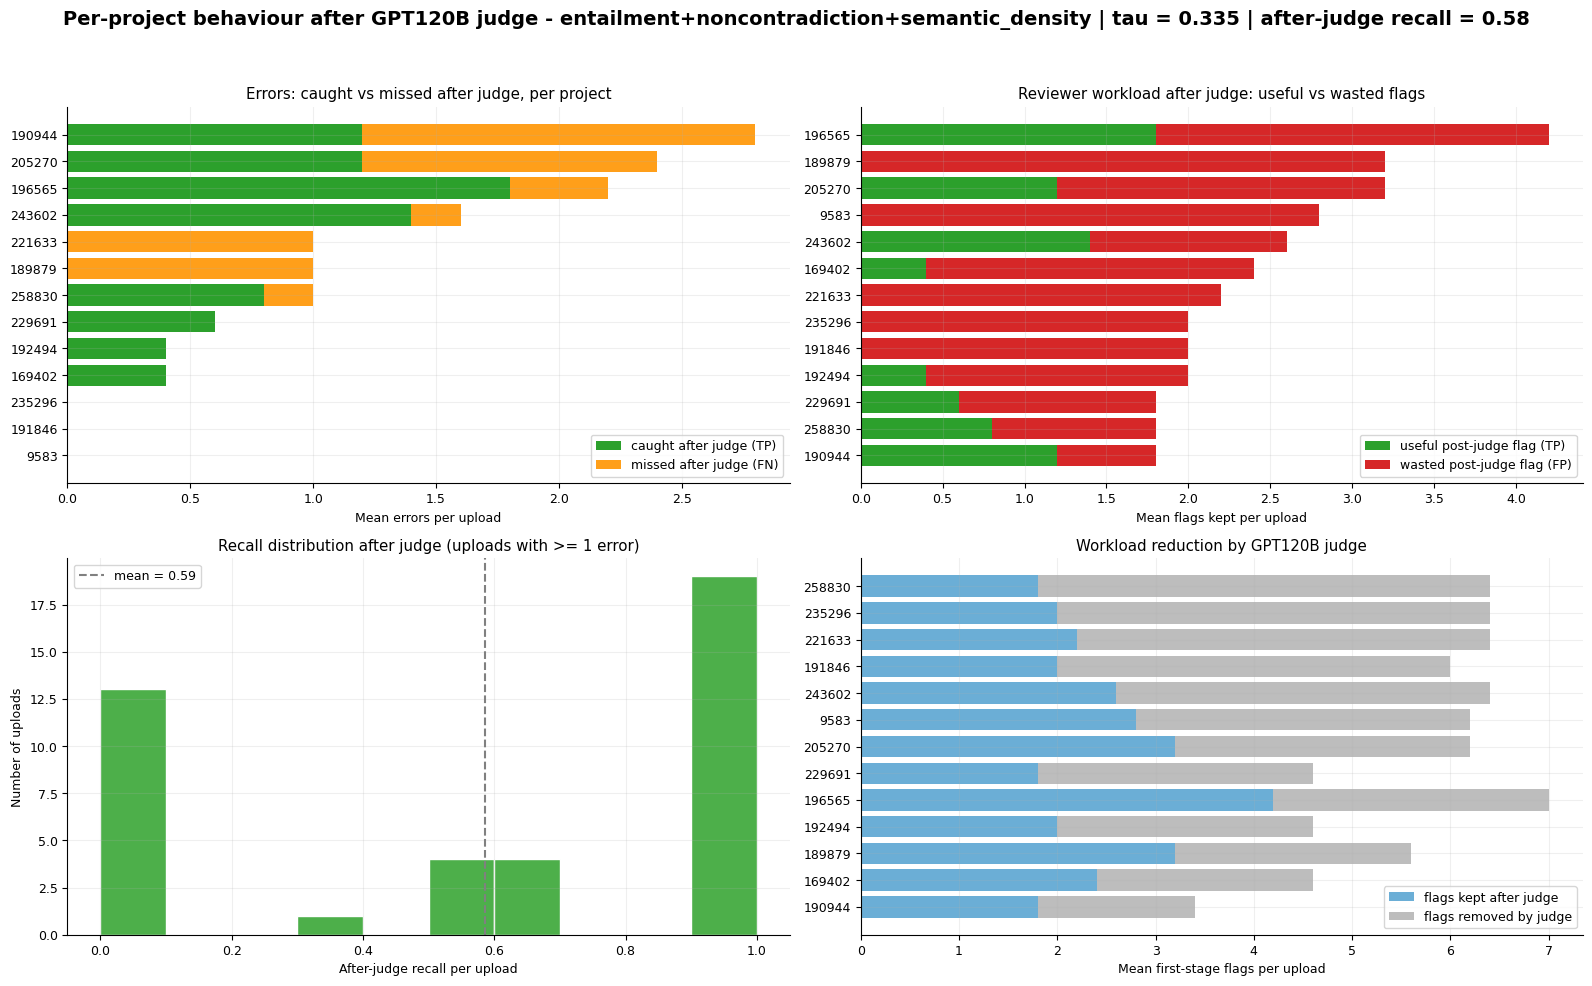

Per-project GPT120B trade-off: removed false positives vs lost true positives


,project_id,removed_flags,removed_fp,lost_tp,after_tp,after_fp,after_fn,after_catch_rate,after_precision
8,221633,4.2,3.4,0.8,0.0,2.2,1.0,0.000,0.000
3,190944,1.6,0.8,0.8,1.2,0.6,1.6,0.433,0.667
7,205270,3.0,2.4,0.6,1.2,2.0,1.2,0.500,0.375
12,258830,4.6,4.6,0.0,0.8,1.0,0.2,0.875,0.444
10,235296,4.4,4.4,0.0,0.0,2.0,0.0,NaN,0.000
4,191846,4.0,4.0,0.0,0.0,2.0,0.0,NaN,0.000
11,243602,3.8,3.8,0.0,1.4,1.2,0.2,0.900,0.538
0,9583,3.4,3.4,0.0,0.0,2.8,0.0,NaN,0.000
6,196565,2.8,2.8,0.0,1.8,2.4,0.4,0.867,0.429
9,229691,2.8,2.8,0.0,0.6,1.2,0.0,1.000,0.333


In [29]:
# Per-project pipeline behaviour after GPT120B judge.
# Self-contained: loads the selected test-level flag file written by the judge cell.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

FLAGS_CANDIDATES = [
    DATA_DIR / "gpt120b_flag_review_test_flags_v3.csv",
    DATA_DIR / "gpt120b_flag_review_test_flags.csv",
]
FLAGS_PATH = next((path for path in FLAGS_CANDIDATES if path.exists()), None)
if FLAGS_PATH is None:
    raise FileNotFoundError(
        "Could not find selected GPT120B judge test flags. Tried: "
        + ", ".join(str(path) for path in FLAGS_CANDIDATES)
    )
print(f"Using judge test flags: {FLAGS_PATH}")

judge_df = pd.read_csv(FLAGS_PATH)

for col in ["ue_flag", "post_judge_flag", "judge_any_suspicious", "judge_all_complete"]:
    if col in judge_df.columns:
        judge_df[col] = judge_df[col].astype(bool)
judge_df["error_label"] = judge_df["error_label"].astype(int)

STAGES = {
    "before_judge": "ue_flag",
    "after_judge": "post_judge_flag",
}

def _stage_metrics(frame, flag_col):
    flag = frame[flag_col].astype(bool)
    err = frame["error_label"].eq(1)
    tp = int((flag & err).sum())
    fp = int((flag & ~err).sum())
    fn = int((~flag & err).sum())
    tn = int((~flag & ~err).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    f2 = 5 * precision * recall / (4 * precision + recall) if (4 * precision + recall) else 0.0
    return {
        "flagged": int(flag.sum()),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
    }

# Mean metrics per ensemble for before/after judge.
stage_rows = []
for stage, flag_col in STAGES.items():
    per_ensemble = []
    for ensemble, ens_df in judge_df.groupby("ensemble", sort=True):
        row = _stage_metrics(ens_df, flag_col)
        row["ensemble"] = ensemble
        per_ensemble.append(row)
    stage_mean = pd.DataFrame(per_ensemble).drop(columns=["ensemble"]).mean(numeric_only=True)
    stage_mean["stage"] = stage
    stage_rows.append(stage_mean)

stage_summary = pd.DataFrame(stage_rows)[[
    "stage", "flagged", "tp", "fp", "fn", "precision", "recall", "f1", "f2"
]].round(3)
print("Before/after GPT120B judge, averaged over ensembles:")
display(stage_summary)

# Upload-level metrics: one upload = one project in one ensemble.
upload_rows = []
for (ensemble, project_id), g in judge_df.groupby(["ensemble", "project_id"], sort=True):
    before = _stage_metrics(g, "ue_flag")
    after = _stage_metrics(g, "post_judge_flag")
    errors_present = int(g["error_label"].sum())
    row = {
        "ensemble": ensemble,
        "project_id": project_id,
        "n_tests": len(g),
        "errors_present": errors_present,
        "before_flagged": before["flagged"],
        "before_tp": before["tp"],
        "before_fp": before["fp"],
        "before_fn": before["fn"],
        "before_catch_rate": before["tp"] / errors_present if errors_present else np.nan,
        "after_flagged": after["flagged"],
        "after_tp": after["tp"],
        "after_fp": after["fp"],
        "after_fn": after["fn"],
        "after_catch_rate": after["tp"] / errors_present if errors_present else np.nan,
        "removed_flags": before["flagged"] - after["flagged"],
        "removed_fp": before["fp"] - after["fp"],
        "lost_tp": before["tp"] - after["tp"],
    }
    upload_rows.append(row)

project_upload_df = pd.DataFrame(upload_rows)
project_summary_after_judge = (
    project_upload_df
    .groupby("project_id", as_index=False)
    .agg(
        uploads=("ensemble", "count"),
        n_tests=("n_tests", "mean"),
        errors_present=("errors_present", "mean"),
        before_flagged=("before_flagged", "mean"),
        after_flagged=("after_flagged", "mean"),
        after_tp=("after_tp", "mean"),
        after_fp=("after_fp", "mean"),
        after_fn=("after_fn", "mean"),
        removed_flags=("removed_flags", "mean"),
        removed_fp=("removed_fp", "mean"),
        lost_tp=("lost_tp", "mean"),
        after_catch_rate=("after_catch_rate", "mean"),
    )
)
project_summary_after_judge["after_precision"] = np.where(
    (project_summary_after_judge["after_tp"] + project_summary_after_judge["after_fp"]) > 0,
    project_summary_after_judge["after_tp"] / (project_summary_after_judge["after_tp"] + project_summary_after_judge["after_fp"]),
    0.0,
)
project_summary_after_judge = project_summary_after_judge.round(3)

print("Per-project behaviour after GPT120B judge:")
display(project_summary_after_judge.sort_values(["errors_present", "after_fn"], ascending=False))

# Plot: after-judge caught/missed errors, workload, catch-rate distribution, workload reduction.
plot_df = project_summary_after_judge.sort_values(["errors_present", "after_fn", "after_tp"], ascending=True)
y = np.arange(len(plot_df))
labels = plot_df["project_id"].astype(str).tolist()
overall_after_catch = project_upload_df["after_tp"].sum() / project_upload_df["errors_present"].sum()
catch_rates_after = project_upload_df.loc[project_upload_df["errors_present"] > 0, "after_catch_rate"].dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "Per-project behaviour after GPT120B judge - "
    "entailment+noncontradiction+semantic_density | "
    "tau = 0.335 | after-judge recall = " + f"{overall_after_catch:.2f}",
    fontsize=14,
    fontweight="bold",
)

ax = axes[0, 0]
ax.barh(y, plot_df["after_tp"], color="#2ca02c", label="caught after judge (TP)")
ax.barh(y, plot_df["after_fn"], left=plot_df["after_tp"], color="#ff9f1a", label="missed after judge (FN)")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Mean errors per upload")
ax.set_title("Errors: caught vs missed after judge, per project")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.2)

work_df = project_summary_after_judge.sort_values(["after_flagged", "after_fp"], ascending=True)
y2 = np.arange(len(work_df))
ax = axes[0, 1]
ax.barh(y2, work_df["after_tp"], color="#2ca02c", label="useful post-judge flag (TP)")
ax.barh(y2, work_df["after_fp"], left=work_df["after_tp"], color="#d62728", label="wasted post-judge flag (FP)")
ax.set_yticks(y2)
ax.set_yticklabels(work_df["project_id"].astype(str))
ax.set_xlabel("Mean flags kept per upload")
ax.set_title("Reviewer workload after judge: useful vs wasted flags")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.2)

ax = axes[1, 0]
ax.hist(catch_rates_after, bins=np.linspace(0, 1, 11), color="#4daf4a", edgecolor="white")
mean_catch = catch_rates_after.mean()
ax.axvline(mean_catch, color="gray", linestyle="--", label=f"mean = {mean_catch:.2f}")
ax.set_xlabel("After-judge recall per upload")
ax.set_ylabel("Number of uploads")
ax.set_title("Recall distribution after judge (uploads with >= 1 error)")
ax.legend(loc="upper left")
ax.grid(axis="both", alpha=0.2)

reduction_df = project_summary_after_judge.sort_values("removed_flags", ascending=True)
y3 = np.arange(len(reduction_df))
ax = axes[1, 1]
ax.barh(y3, reduction_df["after_flagged"], color="#6baed6", label="flags kept after judge")
ax.barh(y3, reduction_df["removed_flags"], left=reduction_df["after_flagged"], color="#bdbdbd", label="flags removed by judge")
ax.set_yticks(y3)
ax.set_yticklabels(reduction_df["project_id"].astype(str))
ax.set_xlabel("Mean first-stage flags per upload")
ax.set_title("Workload reduction by GPT120B judge")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Extra compact diagnostic: where did the judge remove most FPs, and where did it cost TPs?
judge_tradeoff = project_summary_after_judge[[
    "project_id", "removed_flags", "removed_fp", "lost_tp", "after_tp", "after_fp", "after_fn", "after_catch_rate", "after_precision"
]].sort_values(["lost_tp", "removed_fp"], ascending=[False, False]).round(3)
print("Per-project GPT120B trade-off: removed false positives vs lost true positives")
display(judge_tradeoff)



The after-judge project view should be read together with the first-stage project plots above. GPT120B is expected to reduce the red false-positive workload substantially, but it can also remove some true-positive flags. The key question is therefore not only whether the total number of flags decreases, but whether the judge removes false positives more selectively than a stricter threshold-only policy. The matched-recall comparison above shows that it does: at approximately the same recall, the judge keeps fewer false positives than threshold-only baselines.

The per-project plots show whether this benefit is uniform across project IDs. Projects with high remaining red bars still generate wasted review work after the judge, while projects with high orange missed-error bars remain weak spots even after second-stage filtering. These project-level residuals are useful for deciding whether future work should focus on test-specific prompts, scorer features, or specialized review rules.


### Export minimal production config

This cell writes only the operational values needed by production: scorers, threshold, gate, q05/q95 scaling bounds, orientation flips, and GPT120B judge settings. Audit metrics such as recall, TP and FP are intentionally not part of the config.


In [ ]:
# Export minimal production config.
# This writes only the values needed to reproduce the selected UE + GPT120B judge workflow.
import json
BEST_JUDGE_MODEL = "openai/gpt-oss-120b"
BEST_JUDGE_PROMPT_VERSION = "answer_consistency_v3_critical_no_prompt_de"
BEST_JUDGE_TRIAL_NAME = "v3"

active_methods = list(globals().get("UE_METHODS", globals().get("METHODS", BEST_METHODS)))
active_threshold = float(globals().get("UE_THRESHOLD", globals().get("BEST_THRESHOLD", in_sample_threshold)))
active_gate_floor = float(globals().get("UE_GATE_FLOOR", globals().get("BEST_GATE_FLOOR", 0.0)))
active_q_low = float(globals().get("UE_Q_LOW", globals().get("PROD_Q_LOW", 0.05)))
active_q_high = float(globals().get("UE_Q_HIGH", globals().get("PROD_Q_HIGH", 0.95)))

config = {
    "scorers": active_methods,
    "threshold": active_threshold,
    "gate_floor": active_gate_floor,
    "aggregation": "gated_soft_or",
    "scaling": {
        "quantile_levels": [active_q_low, active_q_high],
        "q05": {
            row["method"]: float(row["q05"])
            for _, row in global_params.iterrows()
            if row["method"] in active_methods
        },
        "q95": {
            row["method"]: float(row["q95"])
            for _, row in global_params.iterrows()
            if row["method"] in active_methods
        },
    },
    "orientation_flipped": {
        row["method"]: bool(row["flipped"])
        for _, row in global_params.iterrows()
        if row["method"] in active_methods
    },
    "second_stage_judge": {
        "enabled": True,
        "model": BEST_JUDGE_MODEL,
        "prompt_version": BEST_JUDGE_PROMPT_VERSION,
        "trial_name": BEST_JUDGE_TRIAL_NAME,
        "temperature": 0.0,
        "max_tokens": 500,
        "sees_original_prompt": False,
        "answer_columns": list(globals().get("ANSWER_COLS", [
            "answer_1_original",
            "answer_2_sample",
            "answer_3_sample",
            "answer_4_sample",
            "answer_5_sample",
        ])),
        "decision_rule": "Keep the UE flag only when the judge returns suspicious=true; keep the UE flag on unparsed/error/incomplete judge calls to protect recall.",
    },
}

out_name = f"ensemble_config_threshold_{active_threshold:.3f}_gate_{active_gate_floor:.3f}_.json"
out_path = DATA_DIR / out_name
with open(out_path, "w", encoding="utf-8") as fh:
    json.dump(config, fh, indent=2, ensure_ascii=False)

print(f"Wrote {out_path}\n")
print(json.dumps(config, indent=2, ensure_ascii=False))

assert set(config["scorers"]) == set(active_methods), "scorer set drifted"
assert 0.0 <= config["threshold"] <= 1.0, "threshold out of range"
assert 0.0 <= config["gate_floor"] <= 1.0, "gate out of range"
assert config["aggregation"] == "gated_soft_or", "unexpected aggregation"
assert all(m in config["orientation_flipped"] for m in active_methods), "missing orientation"
assert all(m in config["scaling"]["q05"] and m in config["scaling"]["q95"] for m in active_methods), "missing q05/q95"

